In [21]:
# =========================
# 1) Imports
# =========================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import json
import cv2 as cv      
import random
import joblib

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

# Optionnel: pour affichage
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold

### Helper functions

In [30]:
def plot_samples(xdata, ydata, amount=40):
    for number in range(10):
        indeces = np.random.choice(np.where(ydata == number)[0],size=amount,replace=False)
        fig = plt.figure(figsize=(20,6))
        fig.suptitle("examples for number "+str(number)+":")
        nplt = 1
        for index in indeces:
            ax = fig.add_subplot(4,10,nplt)
            ax.axis('off')
            plt.imshow(xdata[index])
            nplt += 1
    

In [3]:
def rotate_image(image, rotation_angle=0, scale=1):
    height, width = image.shape
    M = cv.getRotationMatrix2D(((width - 1) / 2.0, (height - 1) / 2.0),
                               rotation_angle, scale)
    image_rotated = cv.warpAffine(np.squeeze(image), M, (width, height))

    return image_rotated

In [4]:
def ensure_cnn_input_shape(x, img_h=28, img_w=28):
    if x.ndim == 2:
        x = x.reshape(-1, img_h, img_w, 1)
    elif x.ndim == 3:
        x = np.expand_dims(x, axis=-1)
    return x

In [5]:
def evaluate_sklearn_model(model, x_test, y_test, model_name="model"):
    
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"{model_name} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_weighted": f1
    }

In [6]:
def evaluate_keras_model(model, x_test, y_test, model_name="model"):
    
    y_pred_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"{model_name} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_weighted": f1
    }

In [7]:
def evaluate_all_models(data_name, x_test_data, y_test_data):
    global results

    stacking_result = evaluate_sklearn_model(
        stacking_best,
        x_test_data,
        y_test_data,
        model_name=f"Stacking_{data_name}"
    )
    results.append(stacking_result)

    x_test_data_cnn = ensure_cnn_input_shape(x_test_data)

    for file_name, cnn_model in loaded_cnn_models.items():
        res = evaluate_keras_model(
            cnn_model,
            x_test_data_cnn,
            y_test_data,
            model_name=f"{file_name}_{data_name}"
        )
        results.append(res)

### Load data

In [8]:
x_train = np.load("../processed/X_train_norm.npy")
x_val = np.load("../processed/X_val_norm.npy")
x_test = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val = np.load("../processed/y_val.npy")
y_test = np.load("../processed/y_test.npy")

x_train_final = np.concatenate([x_train, x_val], axis=0)
y_train_final = np.concatenate([y_train, y_val], axis=0)



In [9]:
print(x_train_final.shape, y_train_final.shape)
print(x_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


# Clean data 

Load CNN models:

In [40]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
### Load CNN model from ../models_cnn
models_dir = "../models"

cnn_files = [
    "model_simple.keras",
    "model_drop.keras",
    "model_drop_move.keras",
    "model_drop_full.keras",
]

loaded_cnn_models = {}

for file_name in cnn_files:
    full_path = os.path.join(models_dir, file_name)
    if os.path.exists(full_path):
        loaded_cnn_models[file_name] = load_model(full_path)
        print(f"Loaded : {full_path}")
    else:
        print(f"Not found : {full_path}")
        

Loaded : ../models/model_simple.keras
Loaded : ../models/model_drop.keras
Loaded : ../models/model_drop_move.keras
Loaded : ../models/model_drop_full.keras


Load Stacking model :

In [41]:
stacking_best = joblib.load("../models/stacking_model.joblib")

###################################################################################

Train Stacking model: ( __Already loaded above__ )

In [11]:
stacking_best = StackingClassifier(
    estimators=[
        ("svm", SVC(probability=True)),
        ("knn", KNeighborsClassifier(n_neighbors=3)),
        ("hgb", HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.1,
            max_depth=12,
            random_state=42
        ))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=cv
)

stacking_best.fit(x_train_final, y_train_final)

,estimators,"[('svm', ...), ('knn', ...), ...]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,StratifiedKFo... shuffle=True)
,stack_method,'predict_proba'
,n_jobs,None
,passthrough,False
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [39]:
joblib.dump(stacking_best, "../models/stacking_model.joblib")

['../models/stacking_model.joblib']

##############################################################################################

### Results on clean data : 

In [12]:
results = []
evaluate_all_models("clean", x_test, y_test)

Stacking_clean -> Accuracy: 0.9837 | F1: 0.9837
model_simple.keras_clean -> Accuracy: 0.9851 | F1: 0.9851
model_drop.keras_clean -> Accuracy: 0.9906 | F1: 0.9906
model_drop_move.keras_clean -> Accuracy: 0.9860 | F1: 0.9860
model_drop_full.keras_clean -> Accuracy: 0.9896 | F1: 0.9896


# Image perturbations

## Translation

In [14]:
### reshape it (n_sample, 28, 28)
x_test_img = x_test.reshape(-1, 28, 28)
print(x_test_img.shape)

(10000, 28, 28)


### Big shift:

In [42]:
### -5 , 6
x_test_big_moved = np.zeros(x_test_img.shape)

for i in range(len(x_test_img)):
    shiftx = np.random.randint(-5, 6)
    shifty = np.random.randint(-5, 6)
    for j in range(max(0, shifty), min(28, 28 + shifty)):
        for k in range(max(0, shiftx), min(28, 28 + shiftx)):
            x_test_big_moved[i, j, k] = x_test_img[i, j - shifty, k - shiftx]
            
x_test_big_moved_flat = x_test_big_moved.reshape(len(x_test_big_moved), -1) 

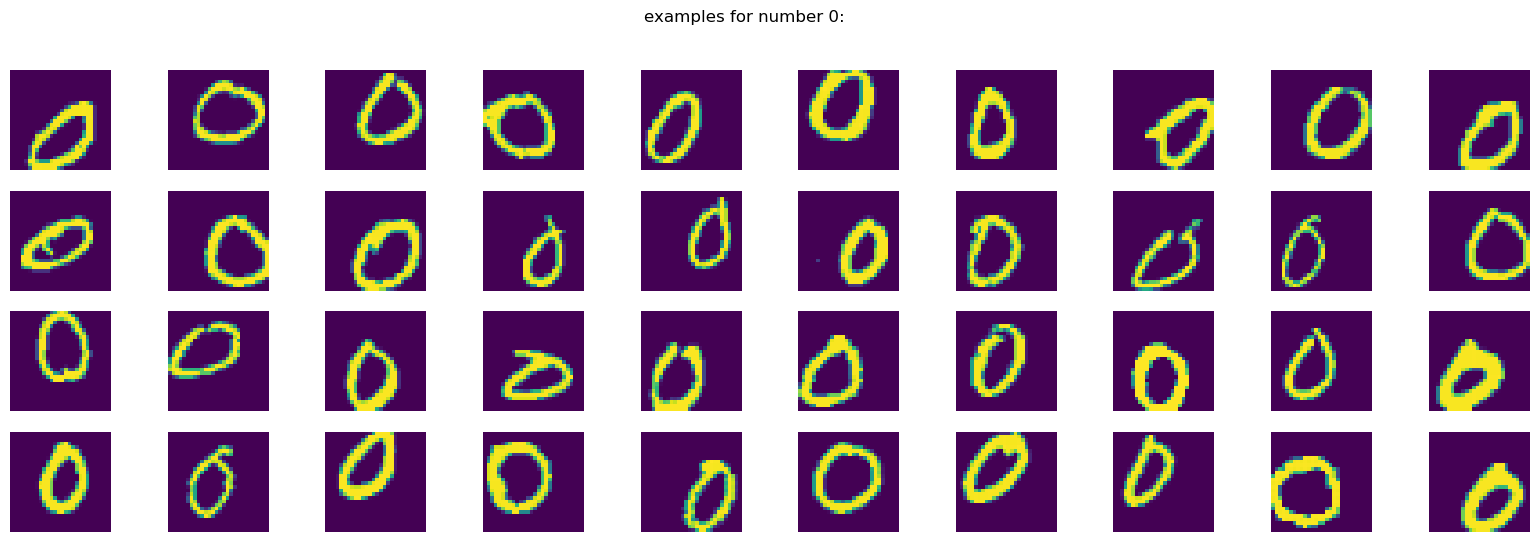

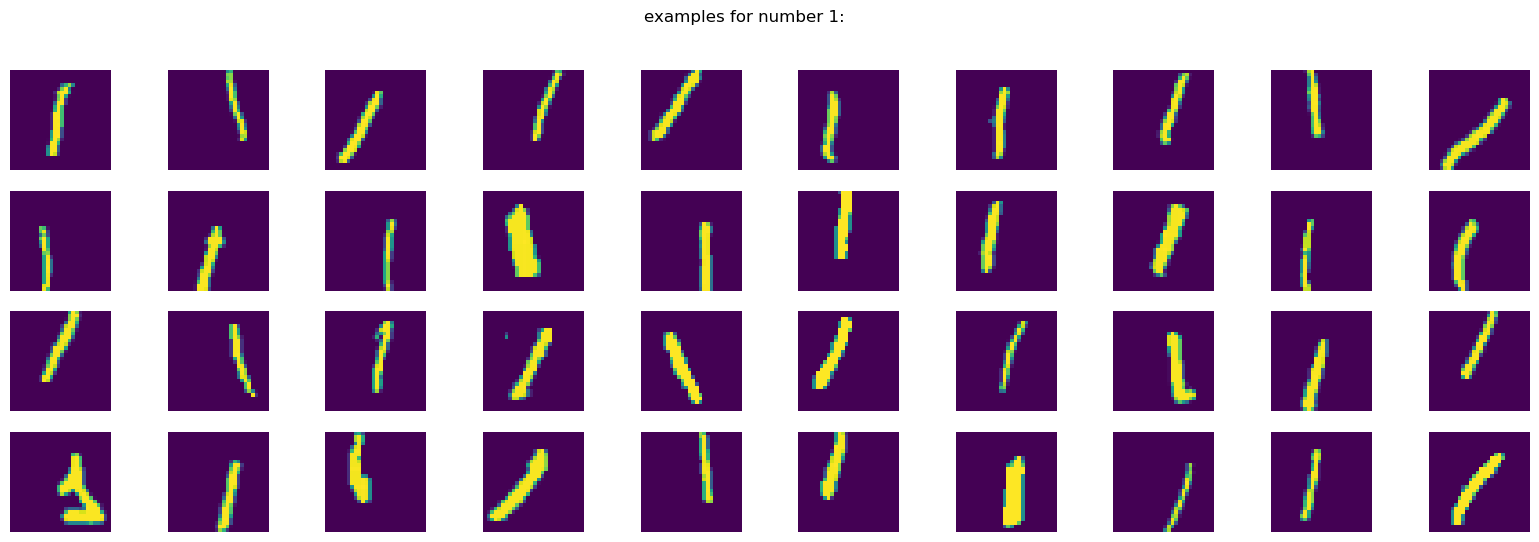

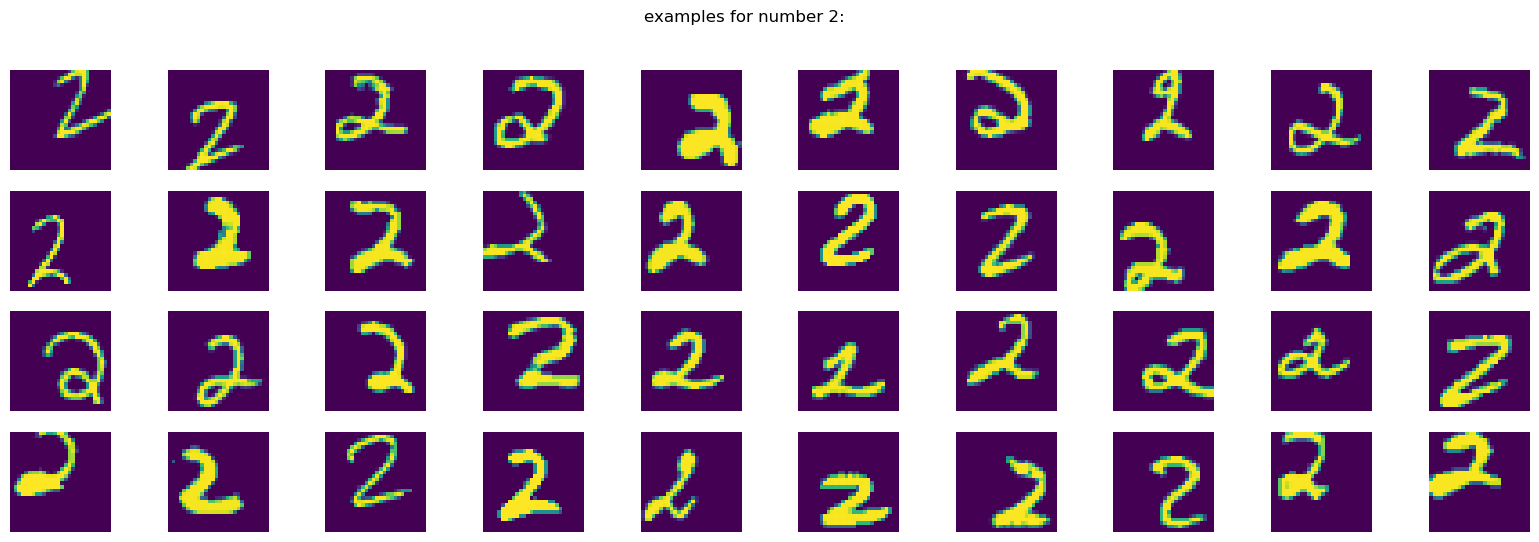

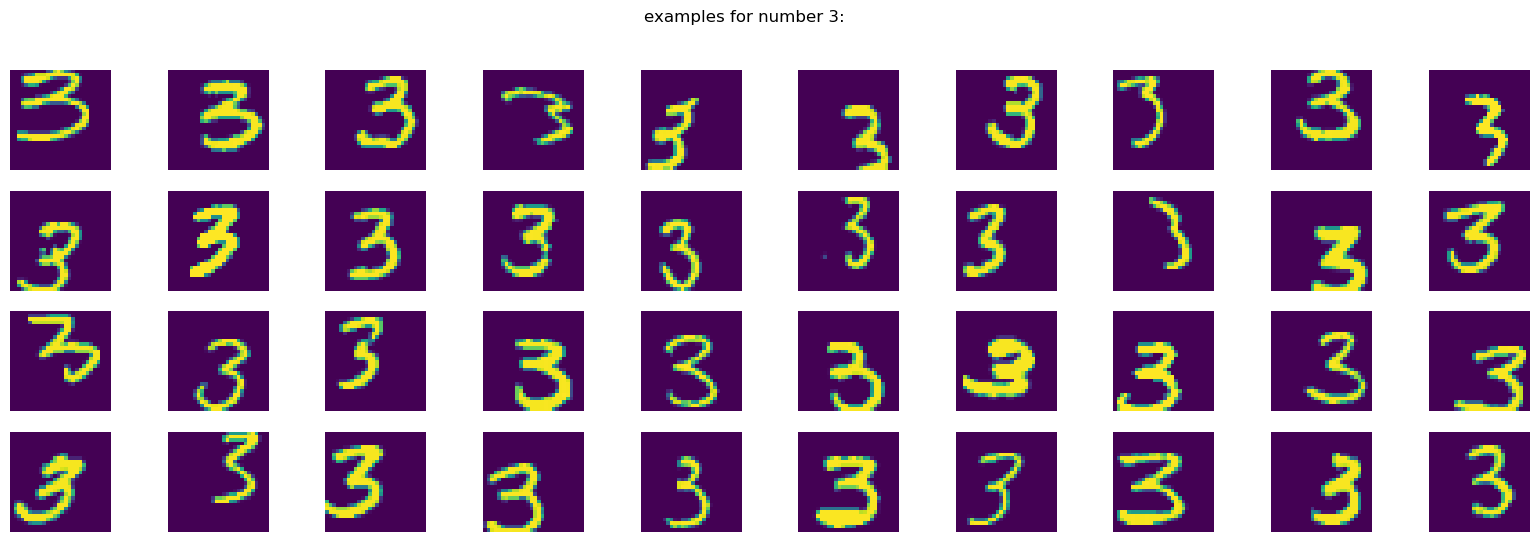

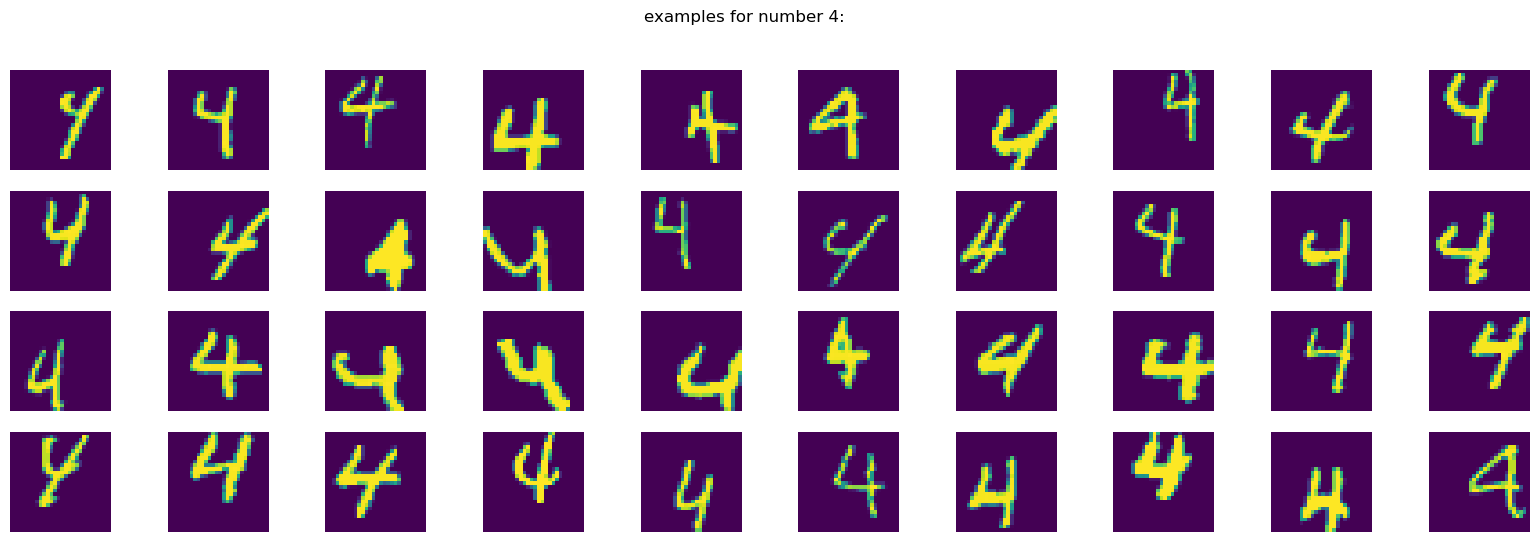

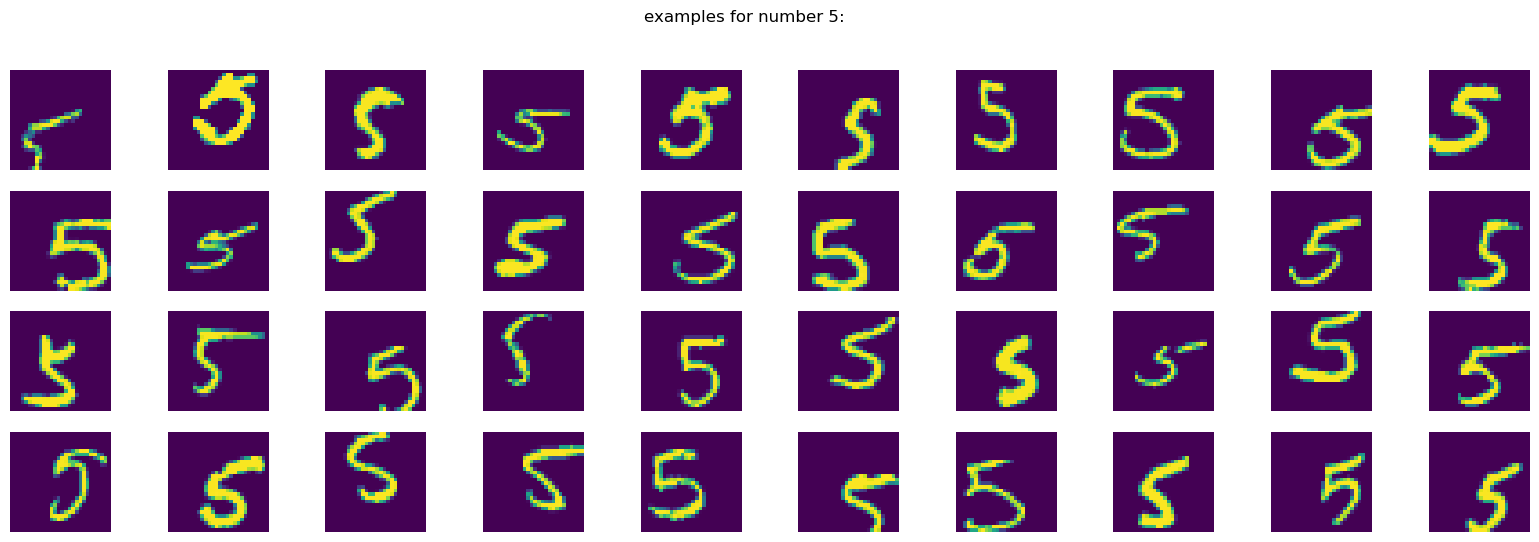

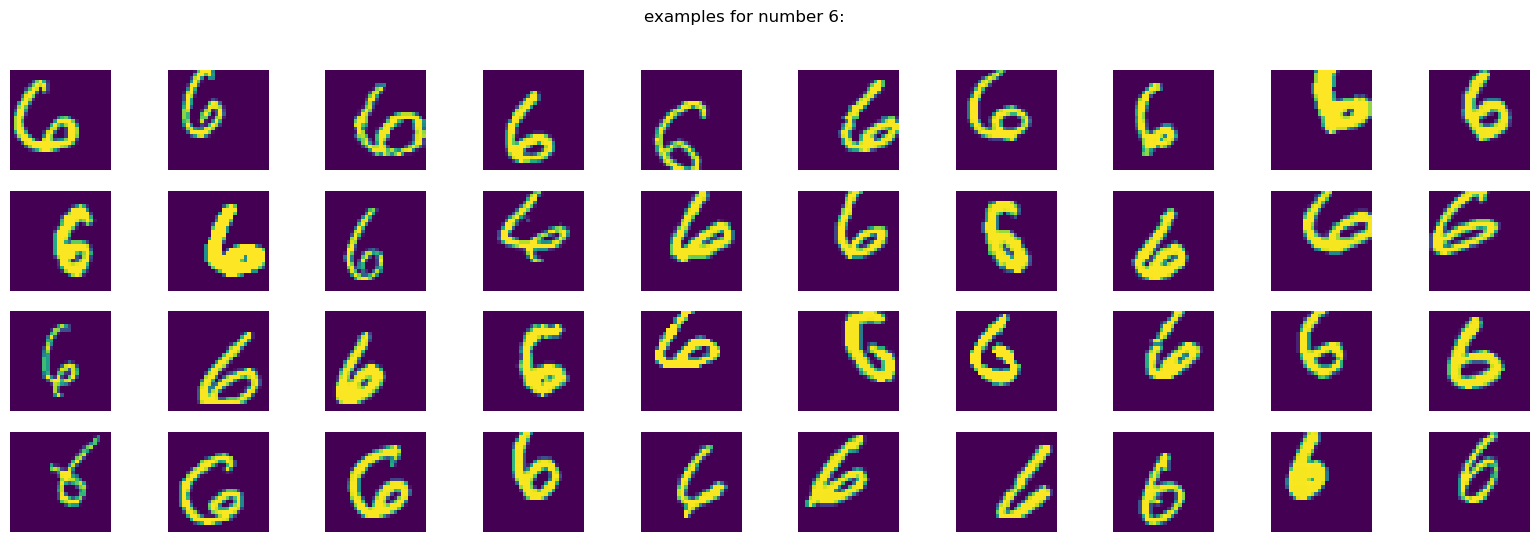

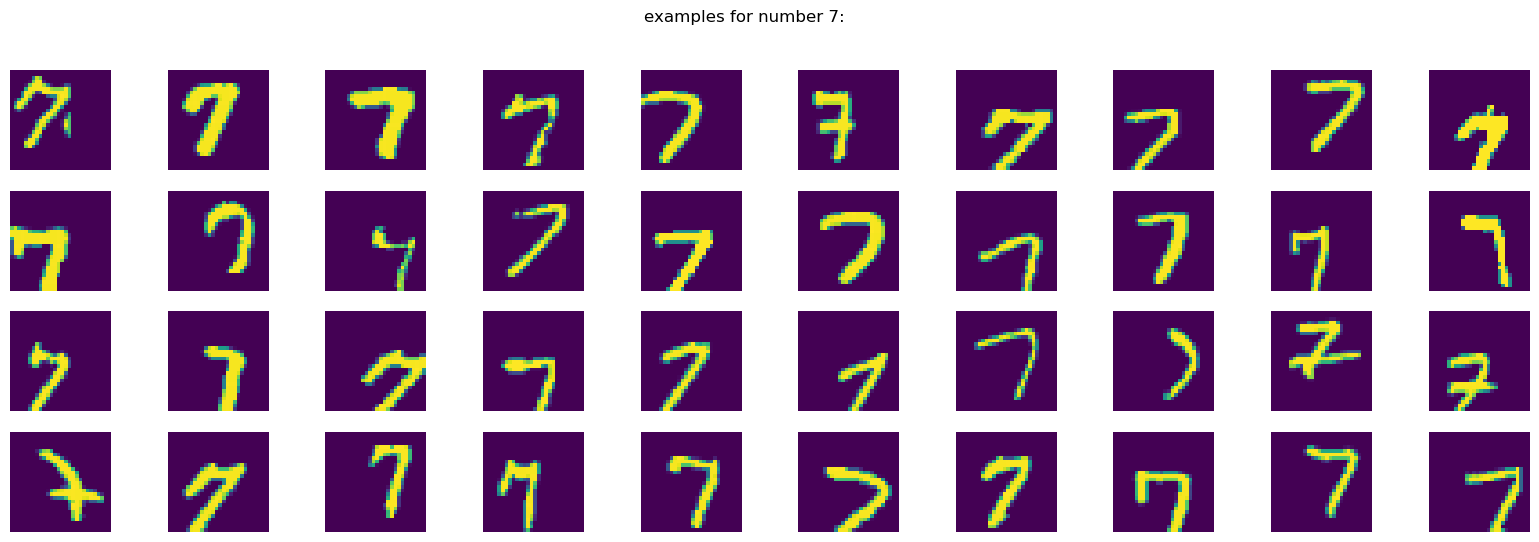

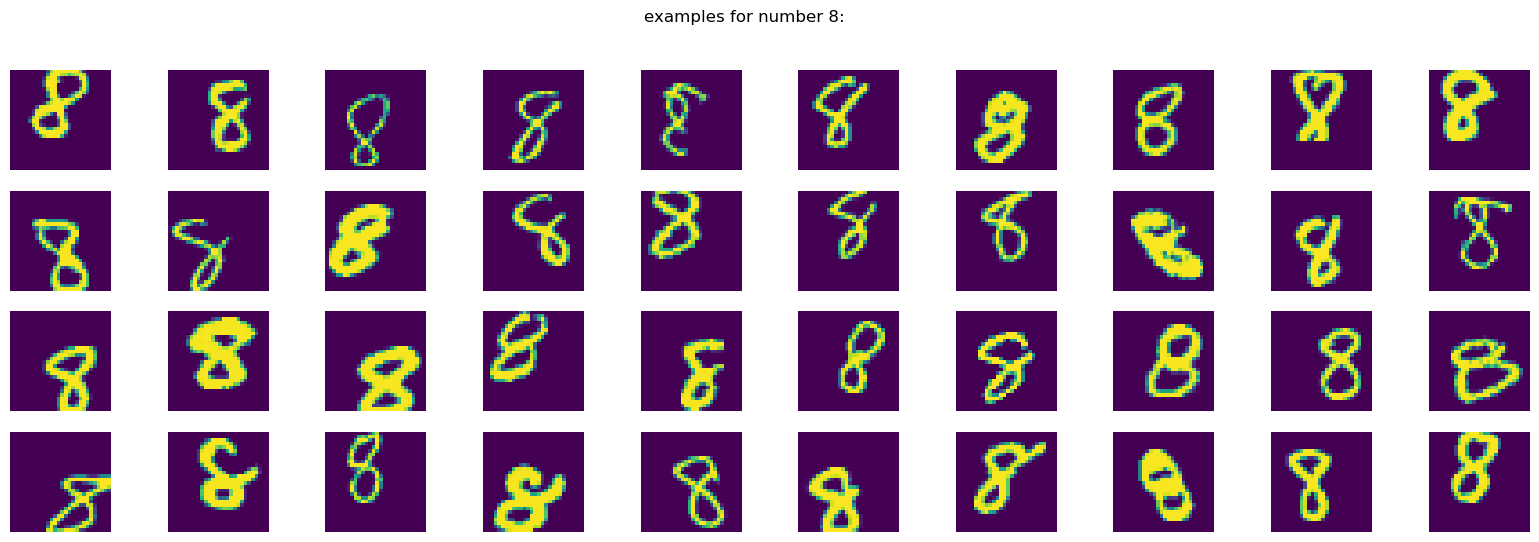

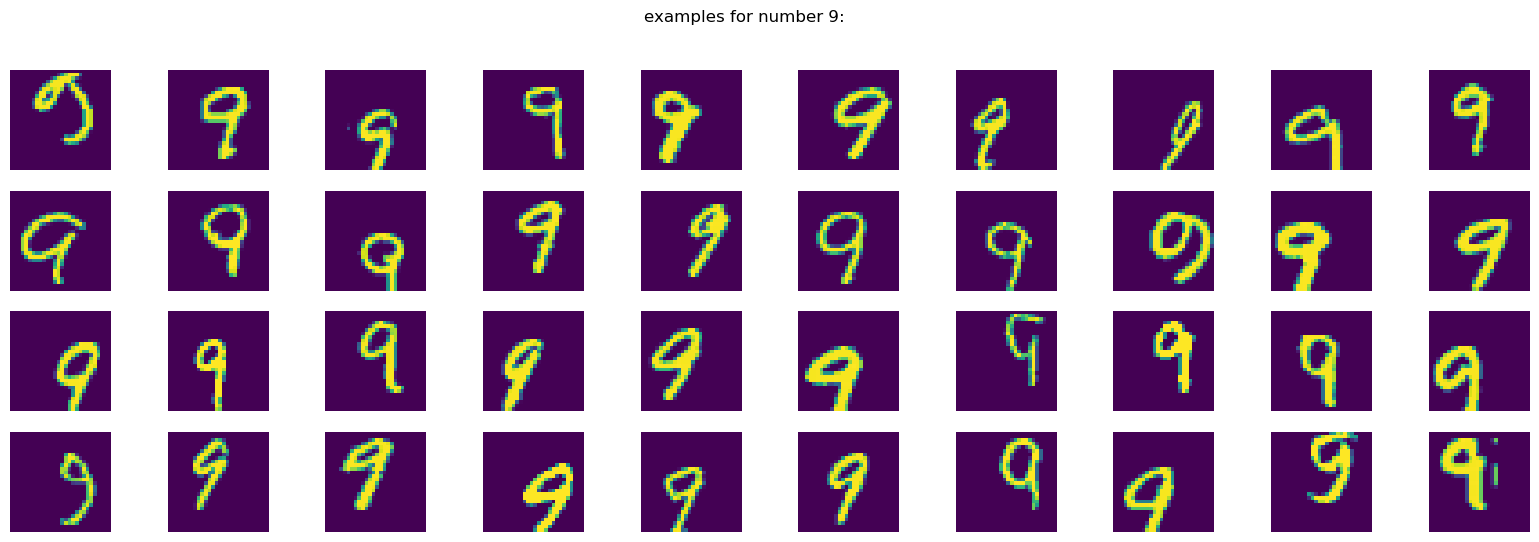

In [43]:
plot_samples(x_test_big_moved,y_test)

### Small shift:

In [33]:
### -5 , 6
x_test_moved = np.zeros(x_test_img.shape)

for i in range(len(x_test_img)):
    shiftx = np.random.randint(-2, 3)
    shifty = np.random.randint(-2, 3)
    for j in range(max(0, shifty), min(28, 28 + shifty)):
        for k in range(max(0, shiftx), min(28, 28 + shiftx)):
            x_test_moved[i, j, k] = x_test_img[i, j - shifty, k - shiftx]
            
x_test_moved_flat = x_test_moved.reshape(len(x_test_moved), -1)            

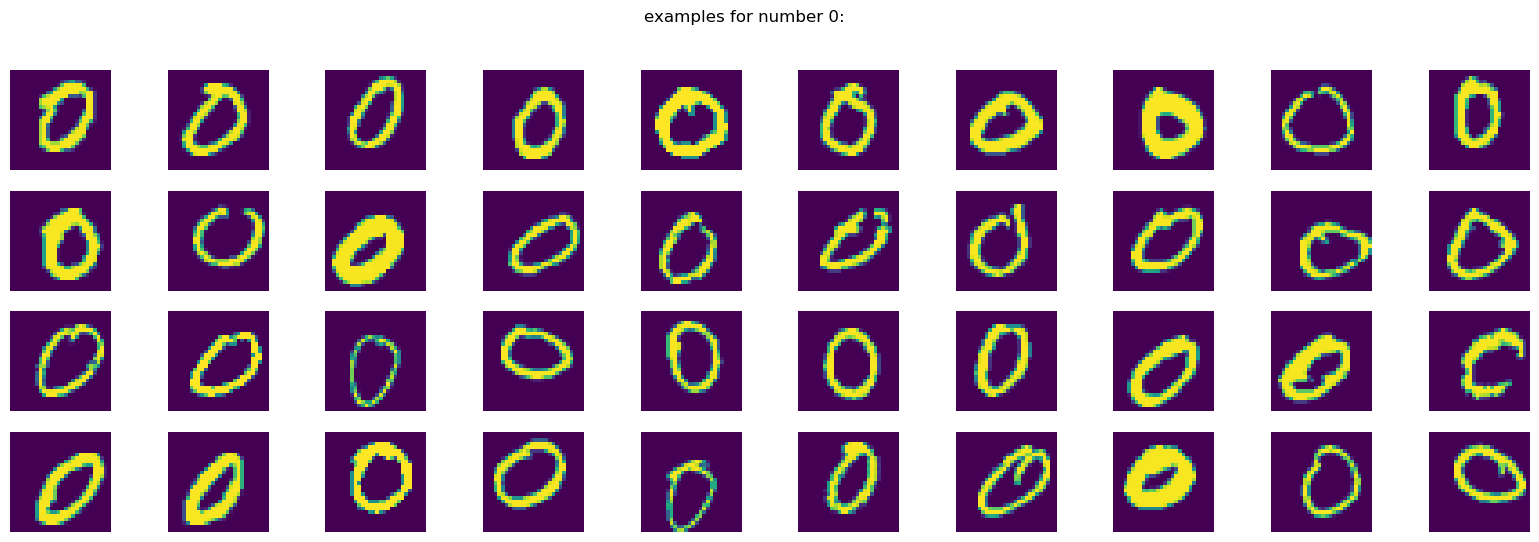

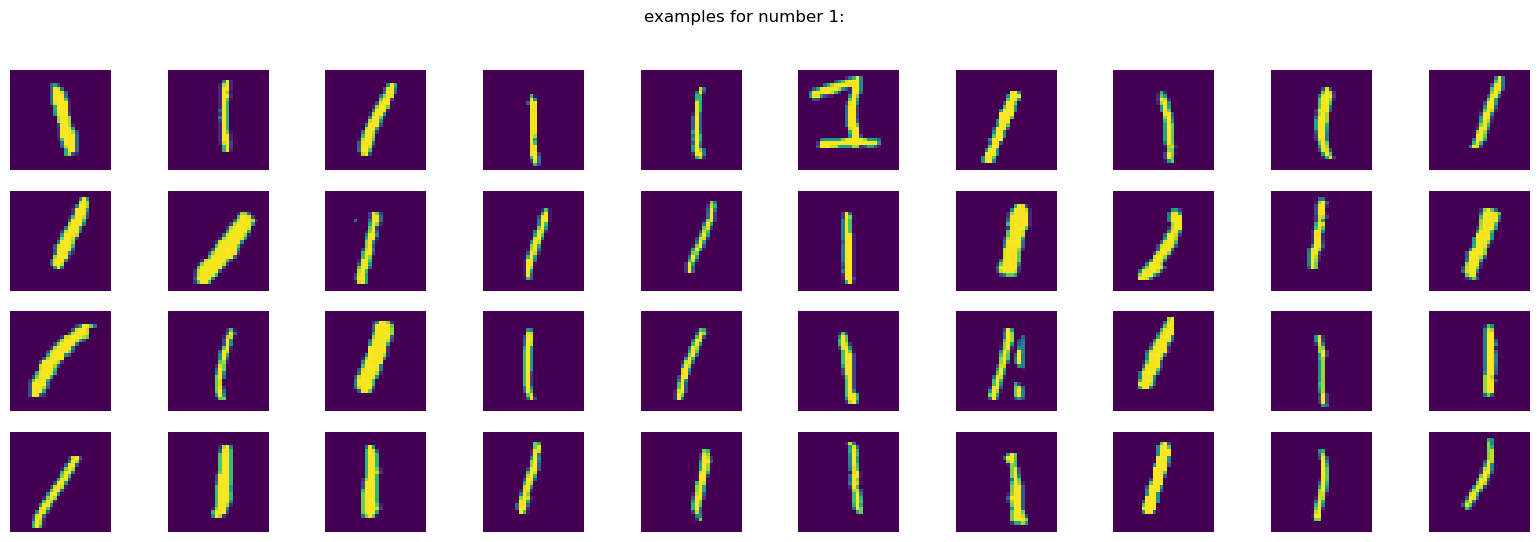

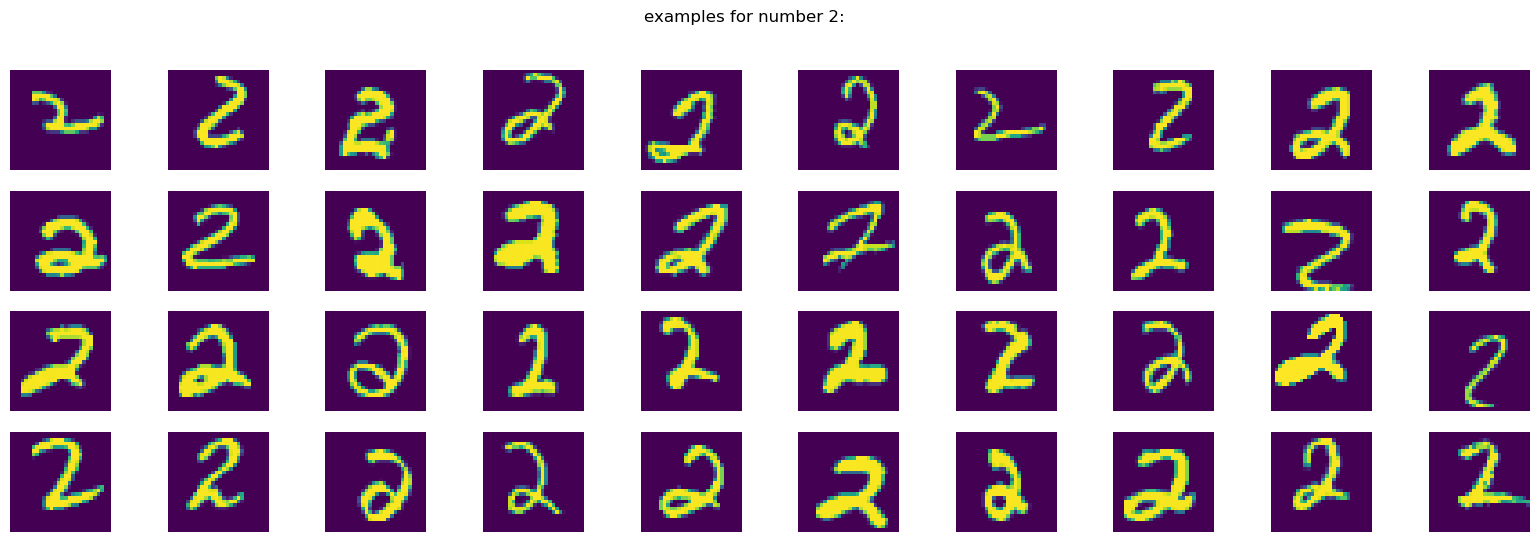

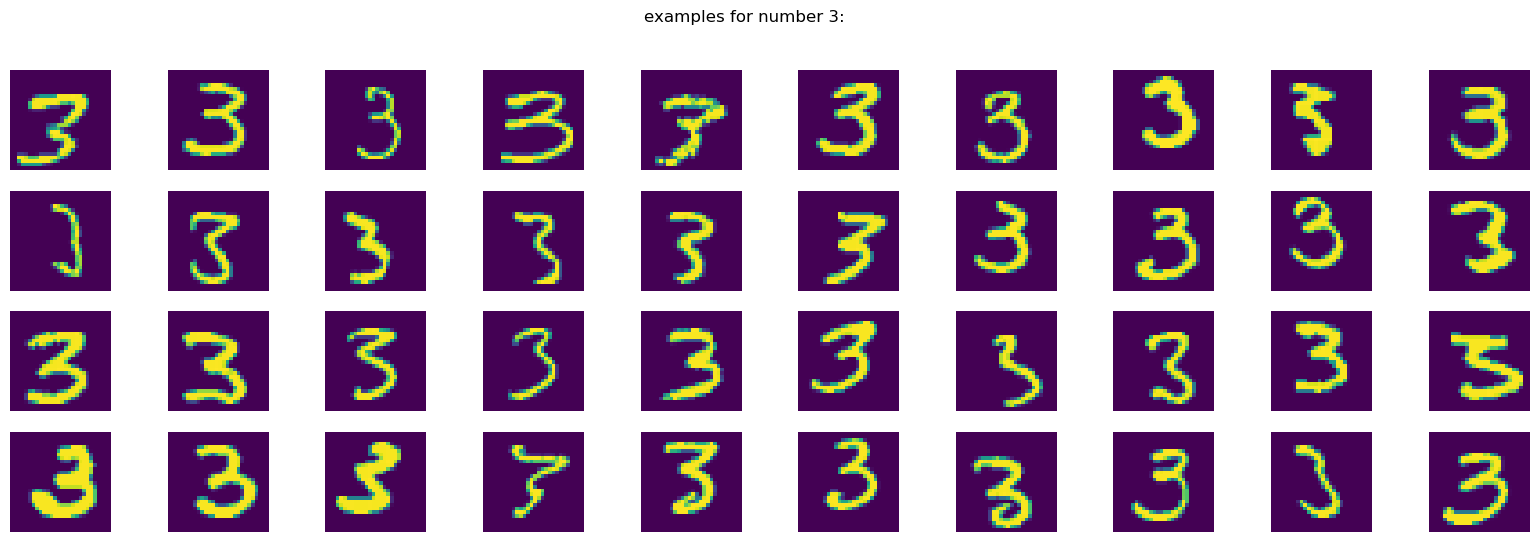

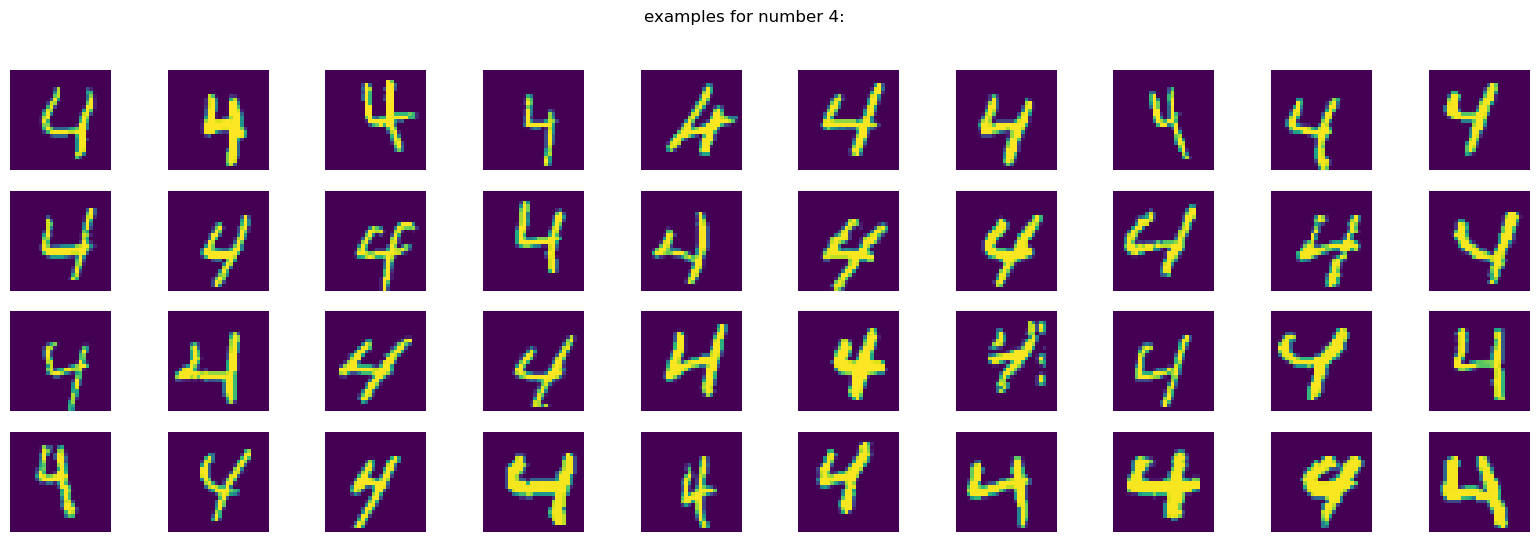

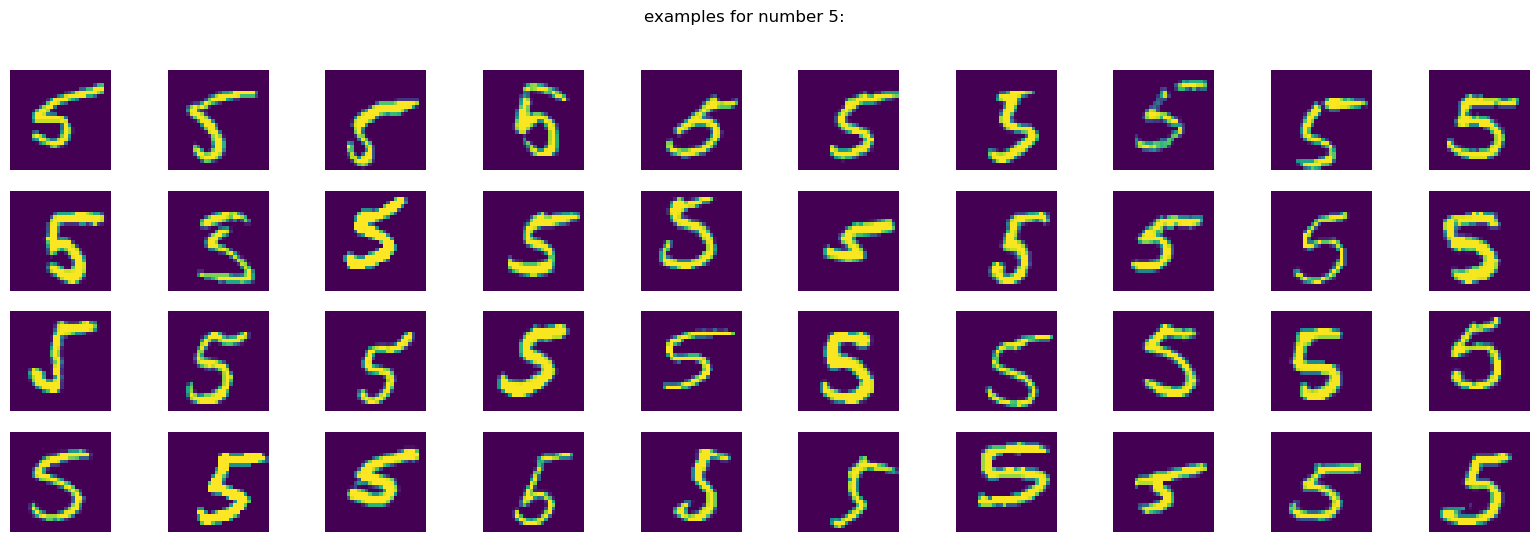

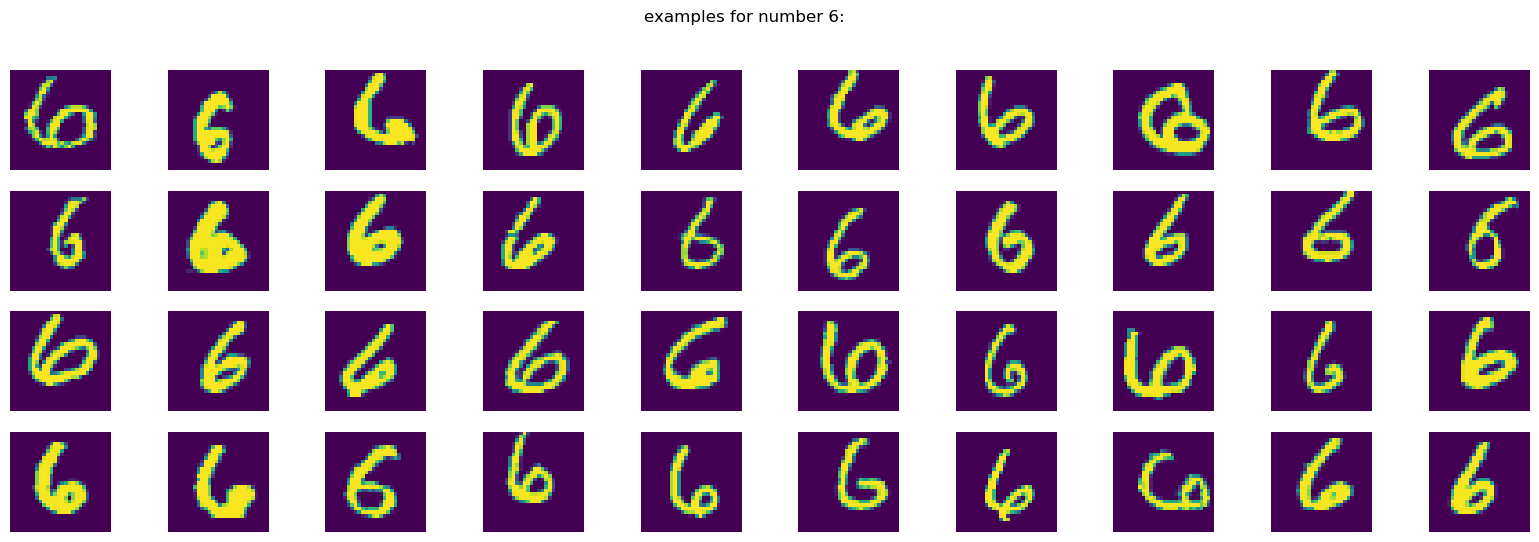

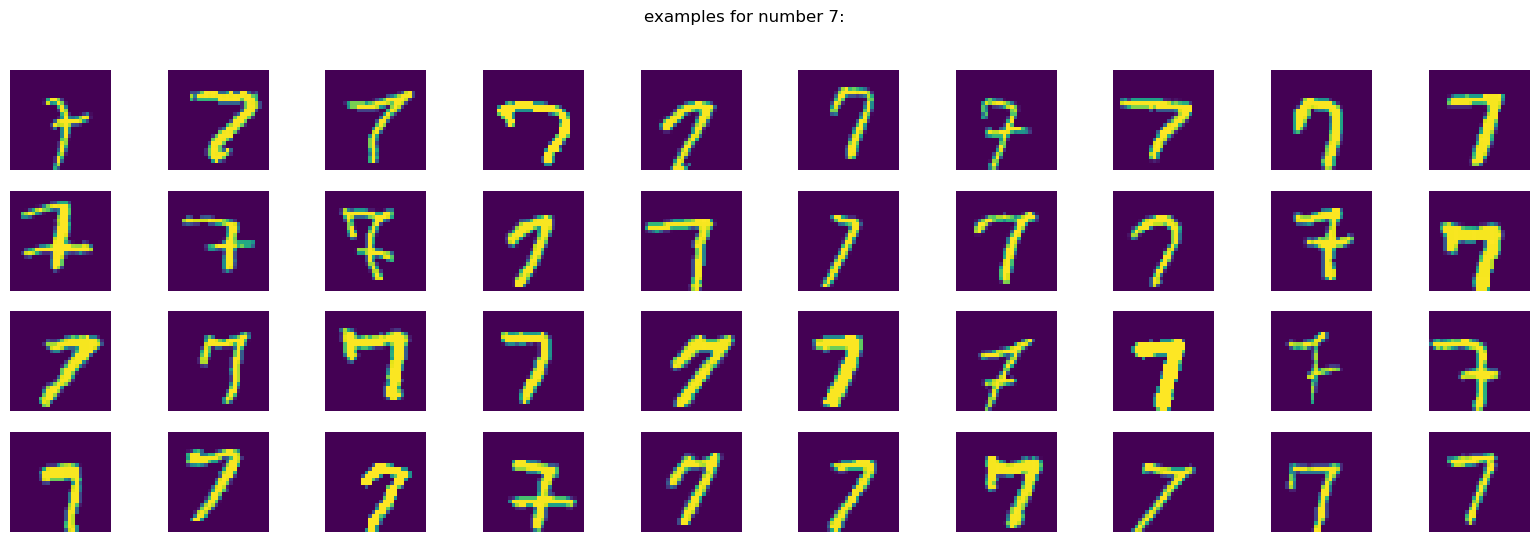

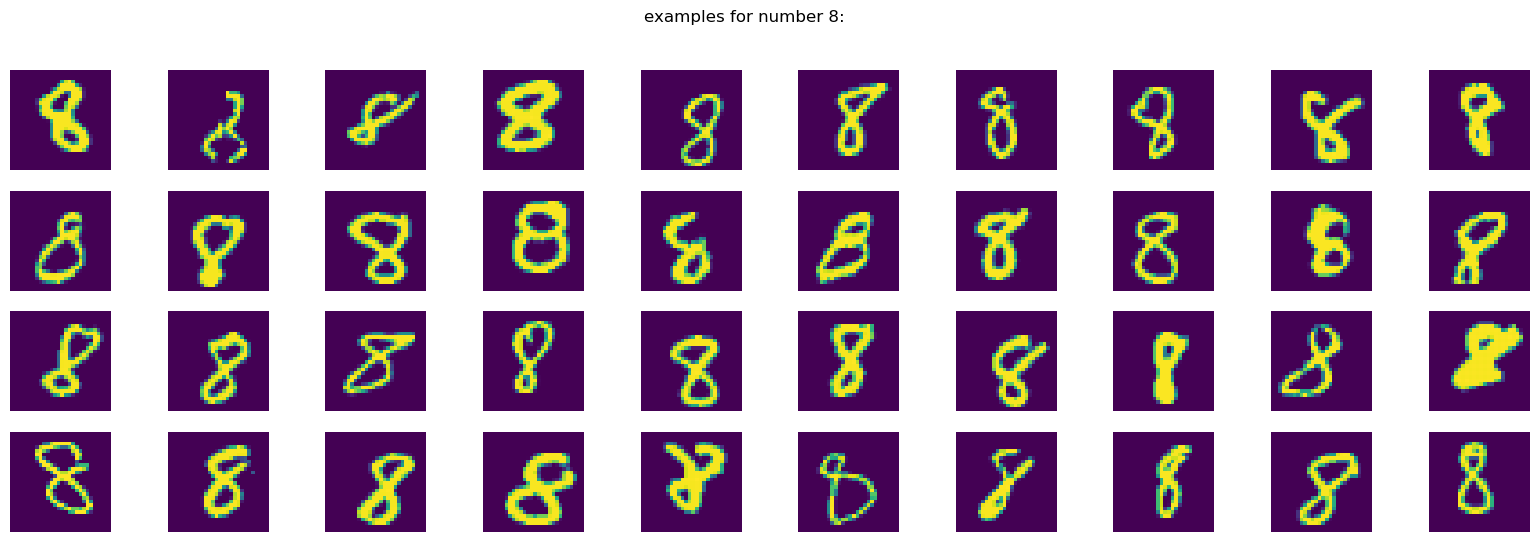

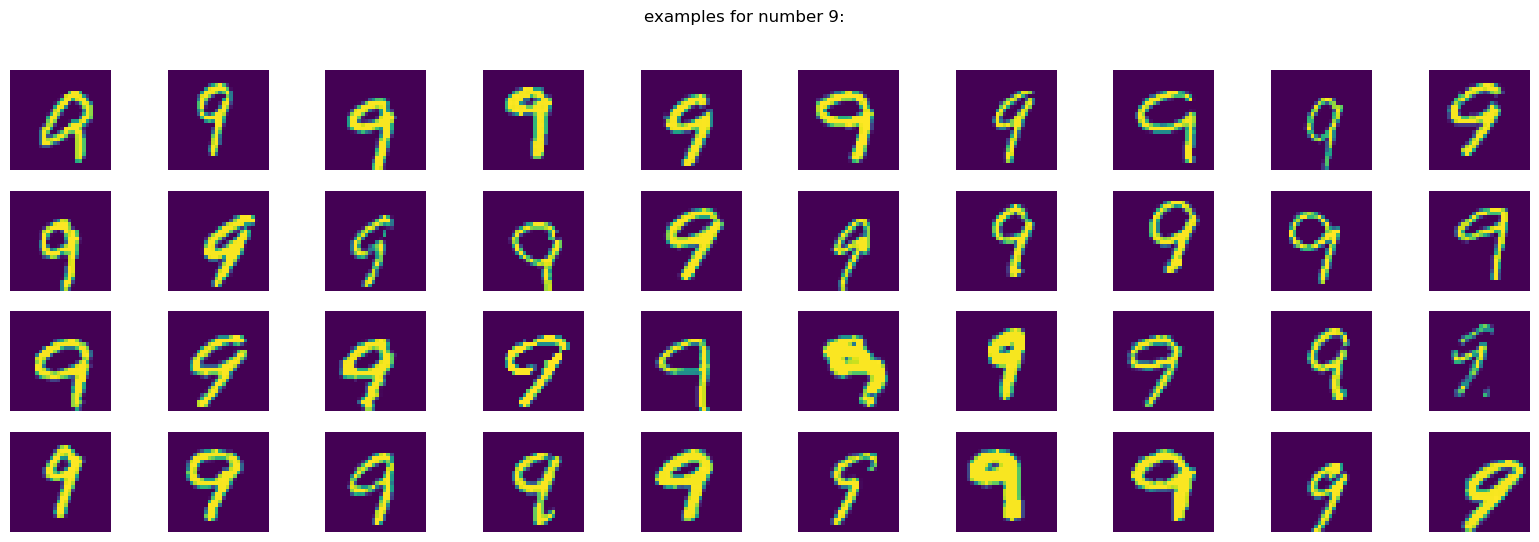

In [34]:
plot_samples(x_test_moved,y_test)

### Results shifted Data:

In [35]:
evaluate_all_models("moved", x_test_moved_flat, y_test)

Stacking_moved -> Accuracy: 0.8209 | F1: 0.8197
model_simple.keras_moved -> Accuracy: 0.8988 | F1: 0.8985
model_drop.keras_moved -> Accuracy: 0.9245 | F1: 0.9245
model_drop_move.keras_moved -> Accuracy: 0.9810 | F1: 0.9810
model_drop_full.keras_moved -> Accuracy: 0.9829 | F1: 0.9829


In [44]:
evaluate_all_models("moved_big", x_test_big_moved_flat, y_test)

Stacking_big_moved -> Accuracy: 0.3538 | F1: 0.3486
model_simple.keras_big_moved -> Accuracy: 0.4925 | F1: 0.4857
model_drop.keras_big_moved -> Accuracy: 0.5141 | F1: 0.5130
model_drop_move.keras_big_moved -> Accuracy: 0.9634 | F1: 0.9634
model_drop_full.keras_big_moved -> Accuracy: 0.9677 | F1: 0.9677


## Rotation

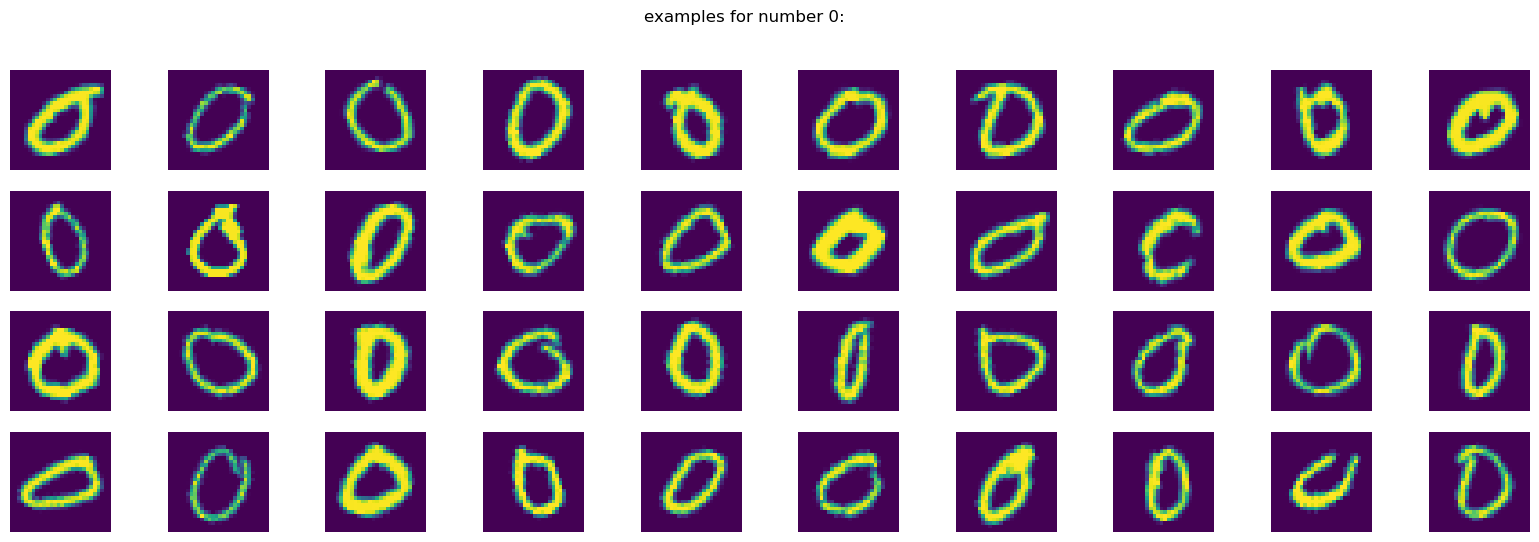

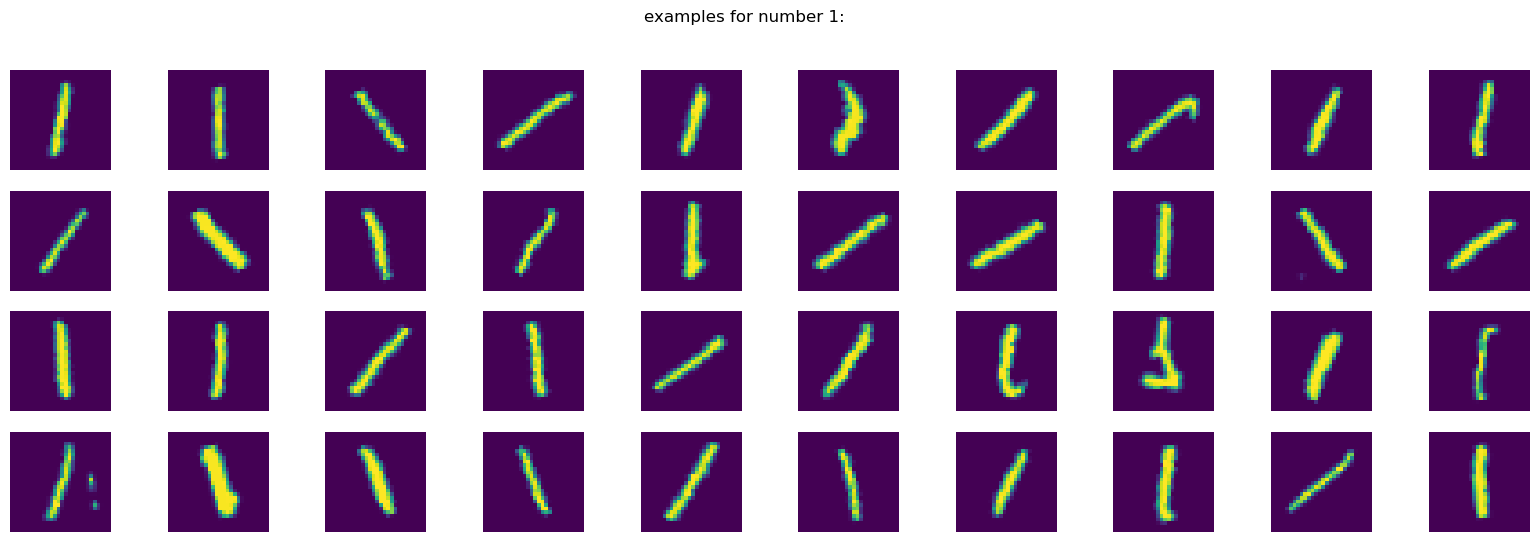

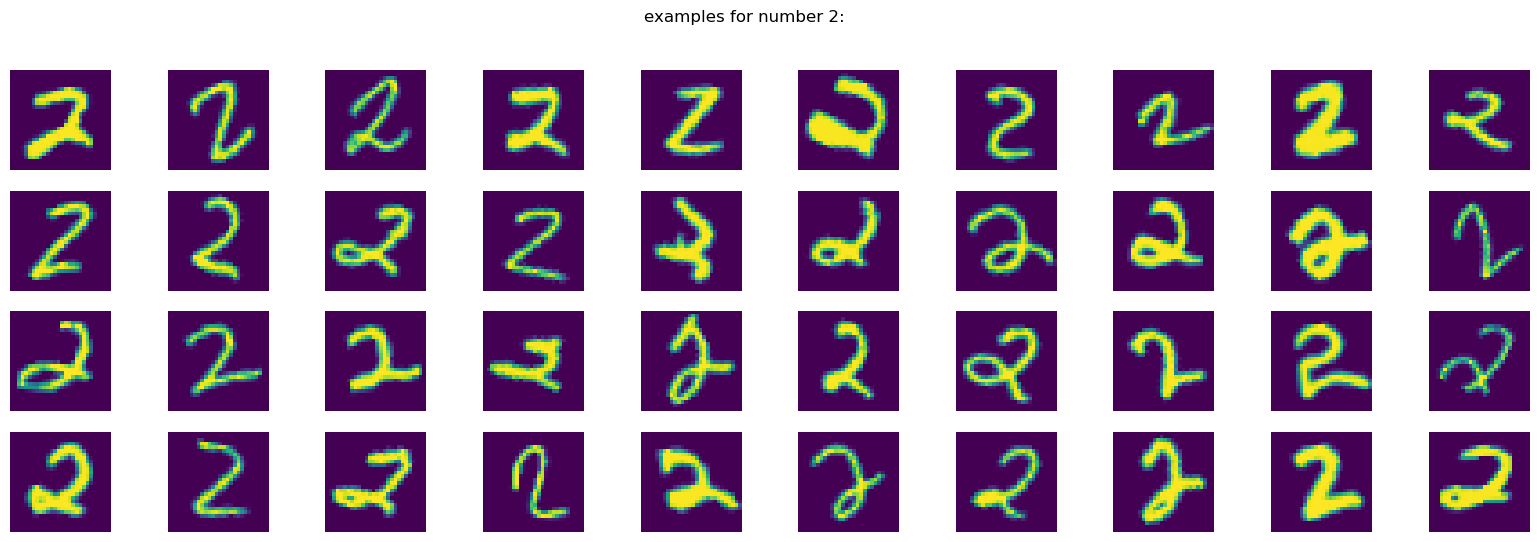

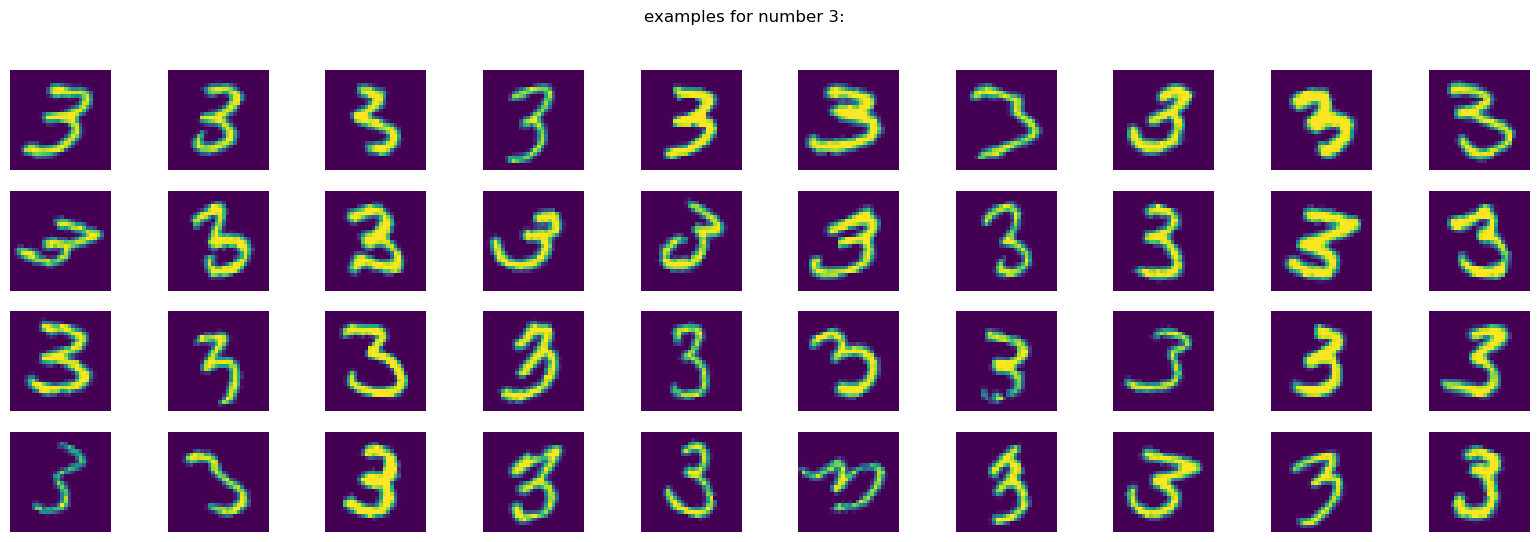

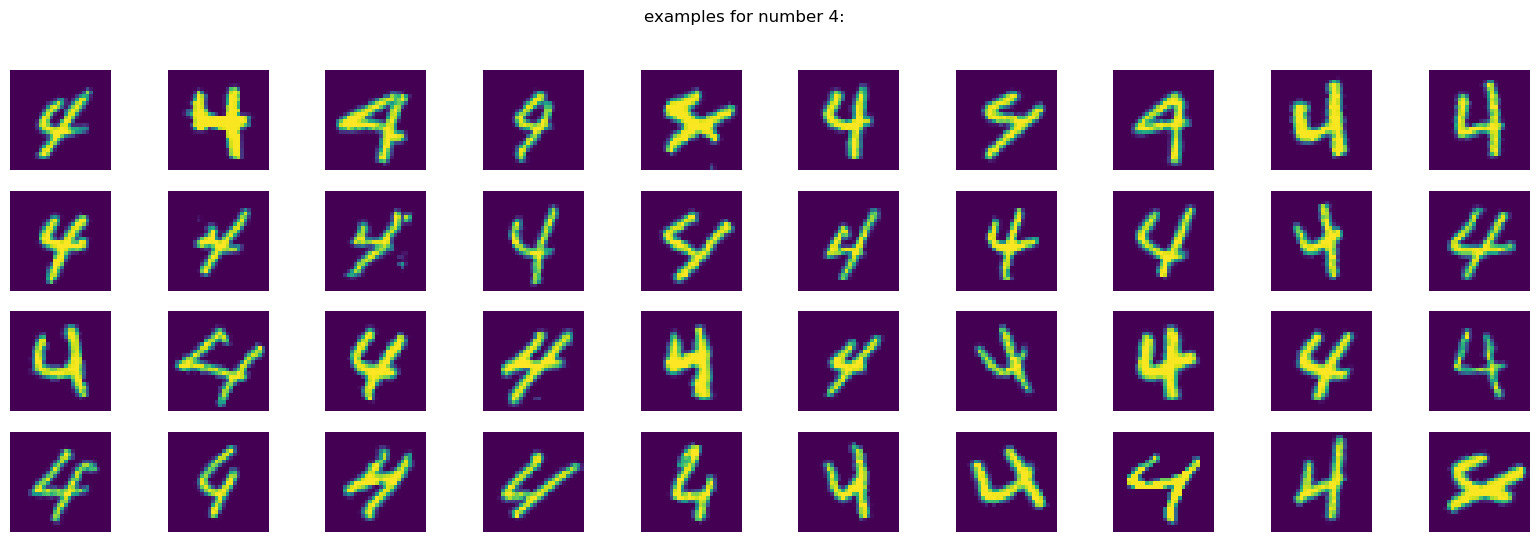

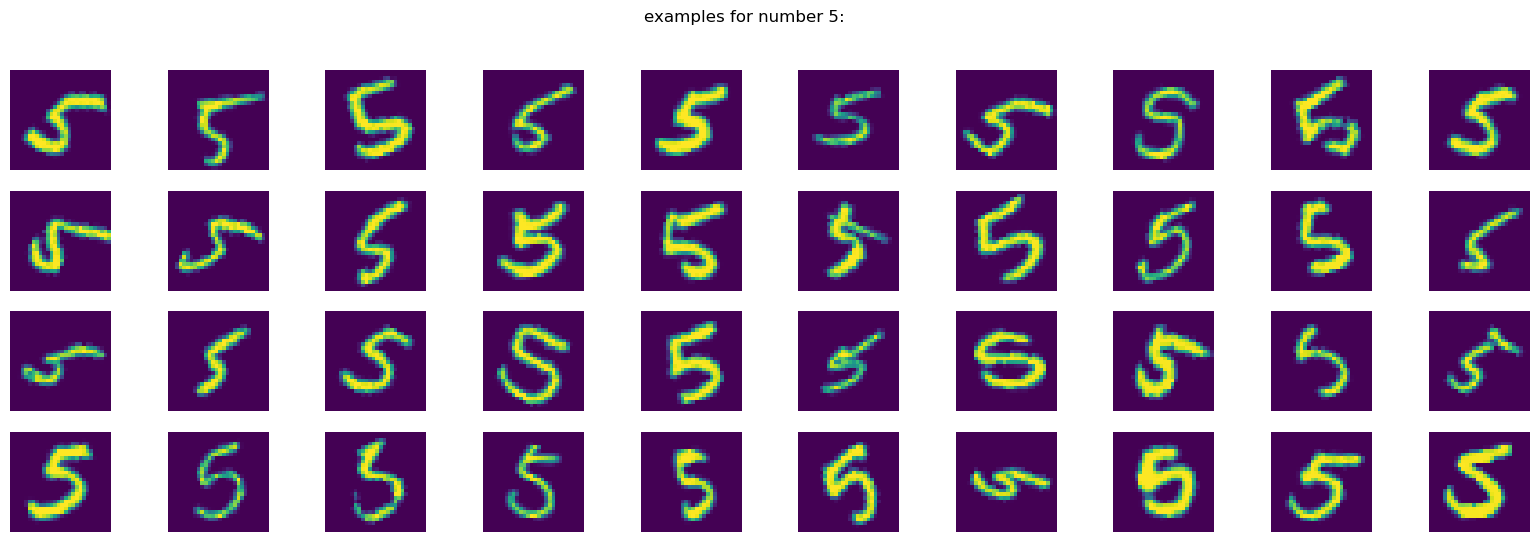

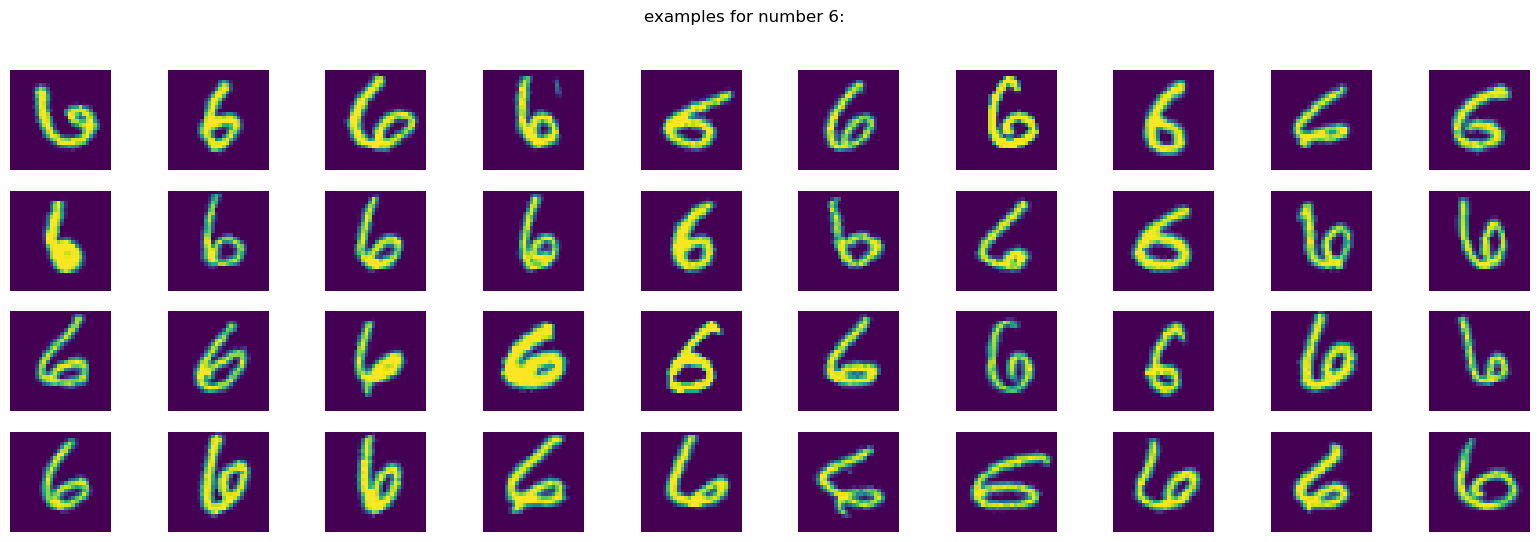

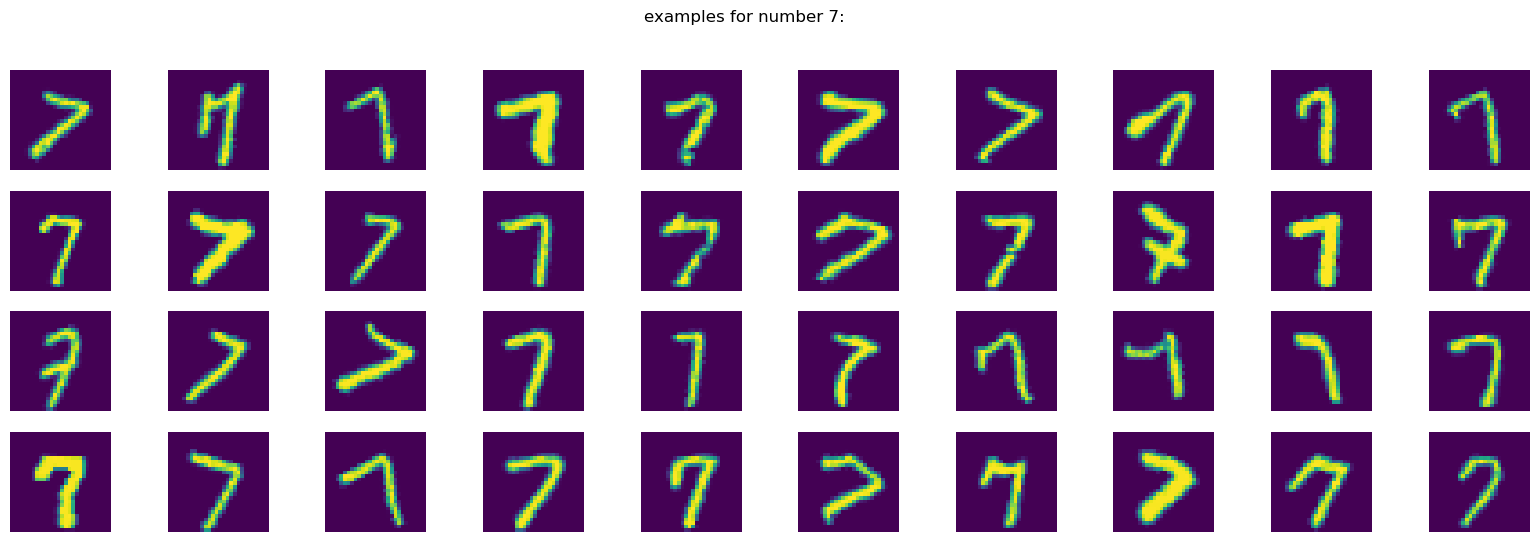

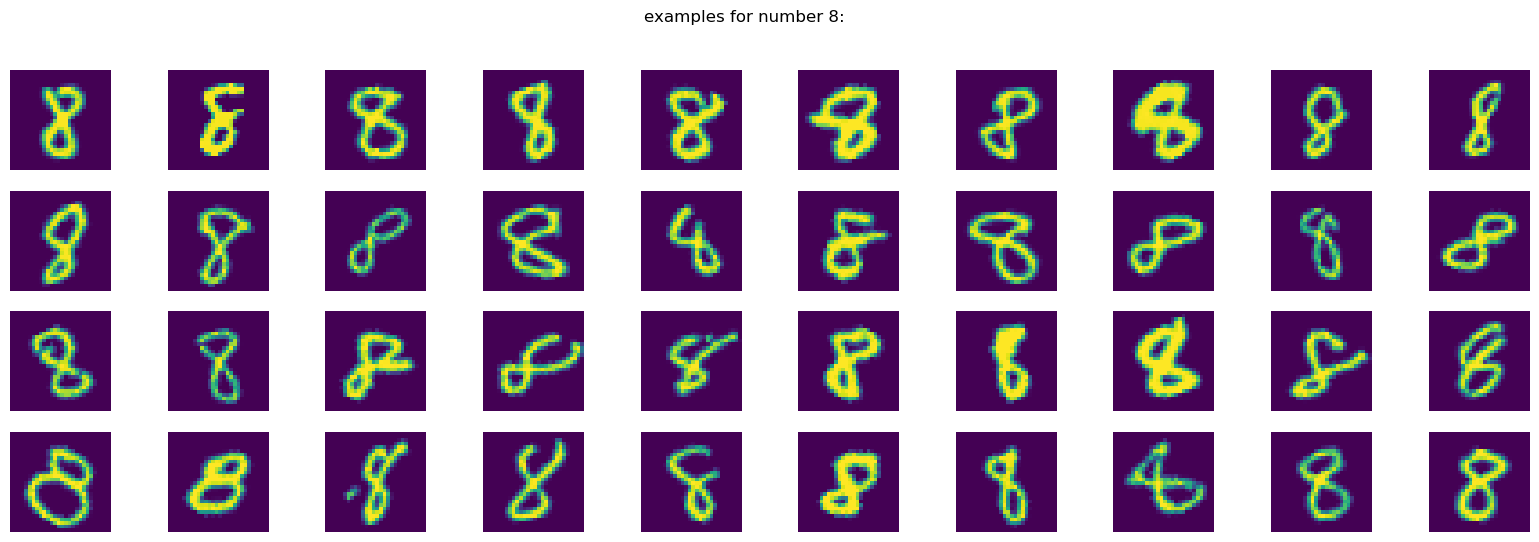

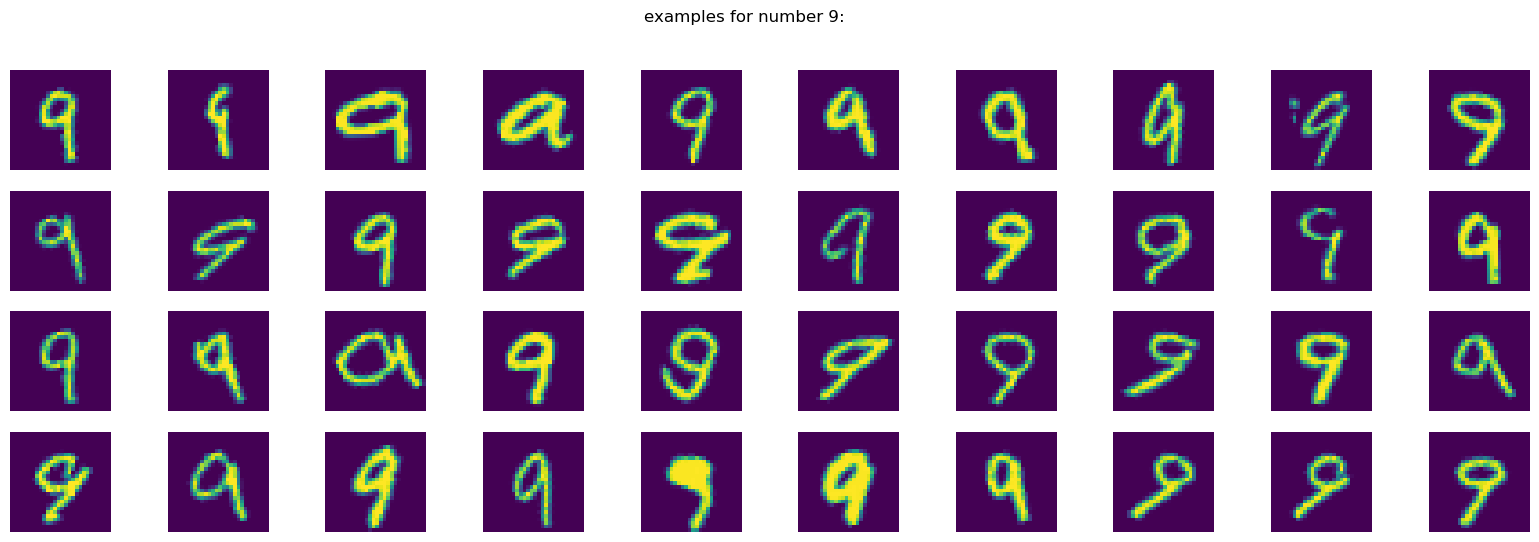

In [19]:
### We will rotate randomly betwenn -30 and 30 degrees.
x_test_rotate = np.zeros(x_test_img.shape)
for i in range(len(x_test_img)):
    x_test_rotate[i,:,:] = rotate_image(x_test_img[i], rotation_angle=np.random.randint(-30, 31))
    
x_test_rotate_flat = x_test_rotate.reshape(len(x_test_rotate), -1)    
### plot pictures
plot_samples(x_test_rotate, y_test)

### Results rotated Data:

In [20]:
evaluate_all_models("rotate", x_test_rotate_flat, y_test)

Stacking_rotate -> Accuracy: 0.9220 | F1: 0.9222
model_simple.keras_rotate -> Accuracy: 0.9231 | F1: 0.9232
model_drop.keras_rotate -> Accuracy: 0.9448 | F1: 0.9448
model_drop_move.keras_rotate -> Accuracy: 0.9250 | F1: 0.9249
model_drop_full.keras_rotate -> Accuracy: 0.9817 | F1: 0.9817


### Mixed = clean / moved / rotated Data

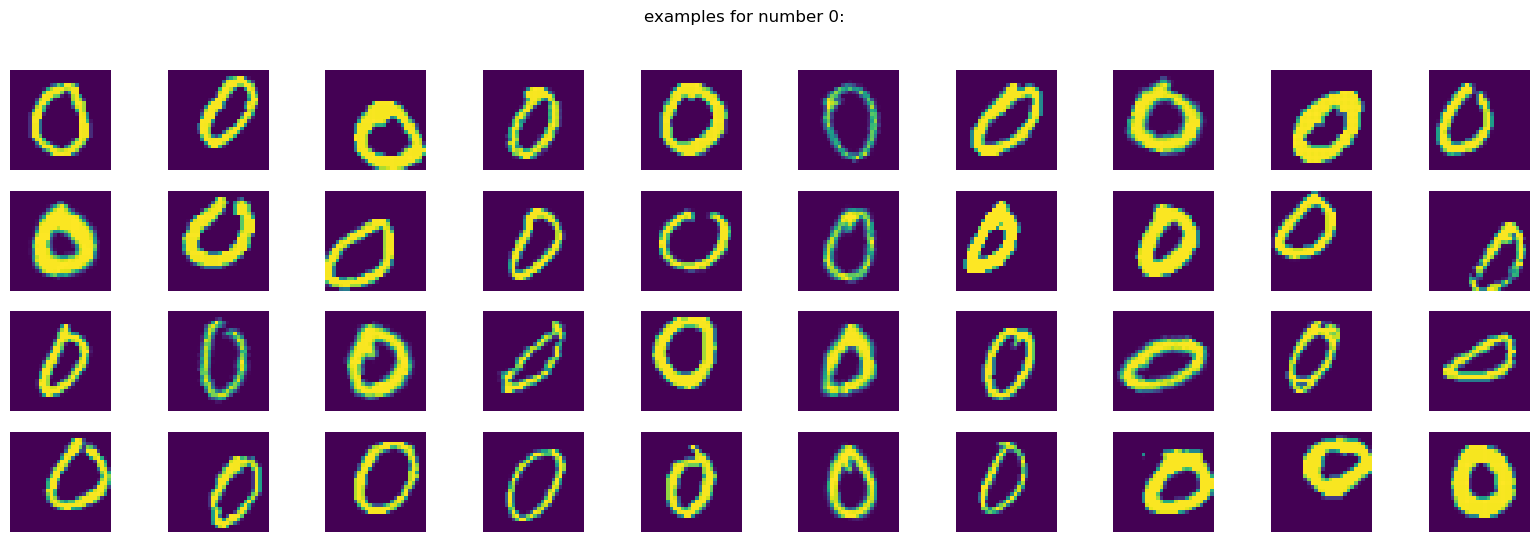

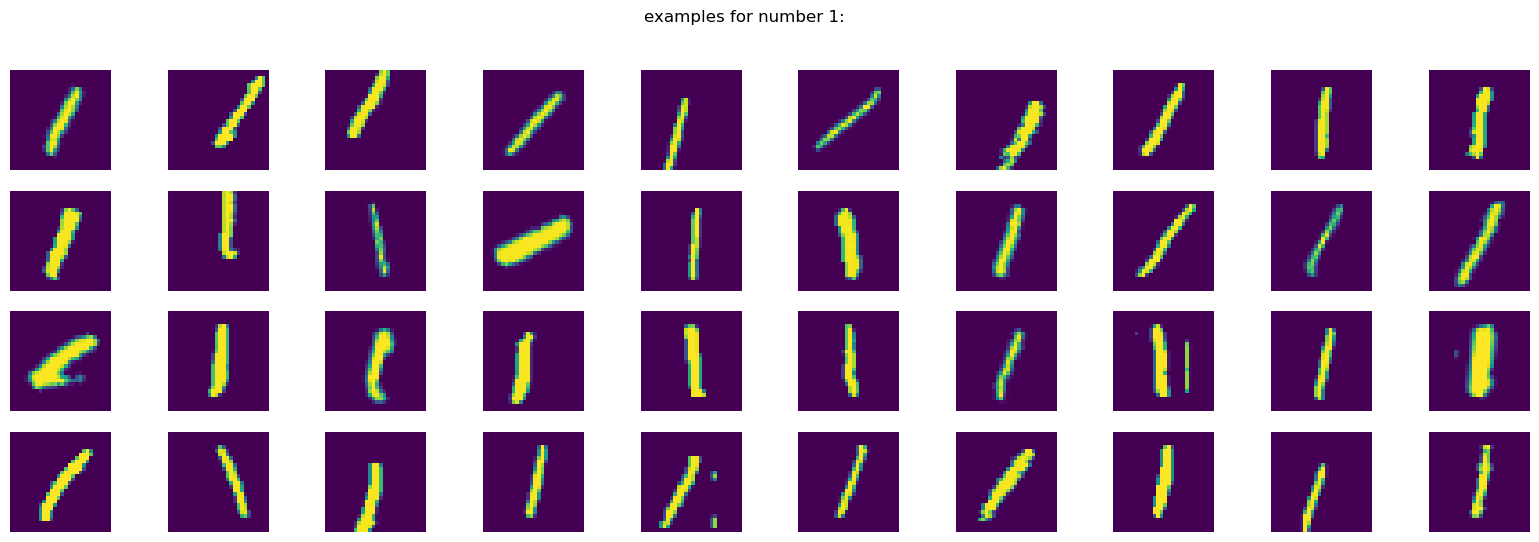

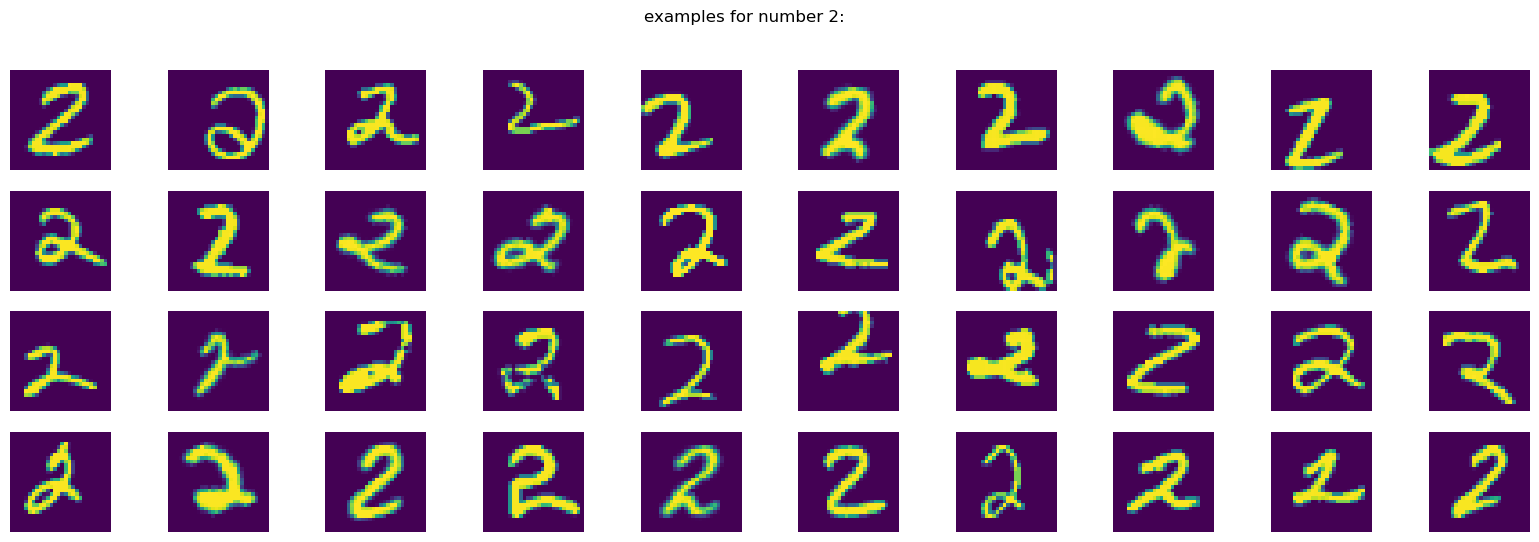

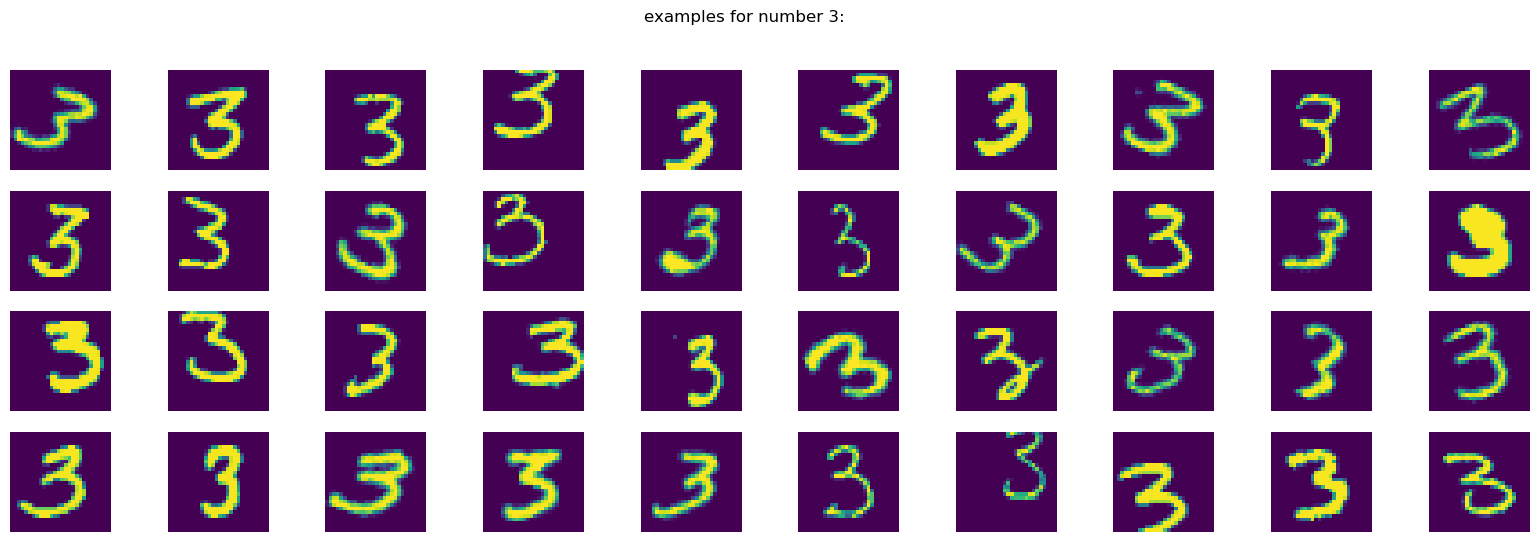

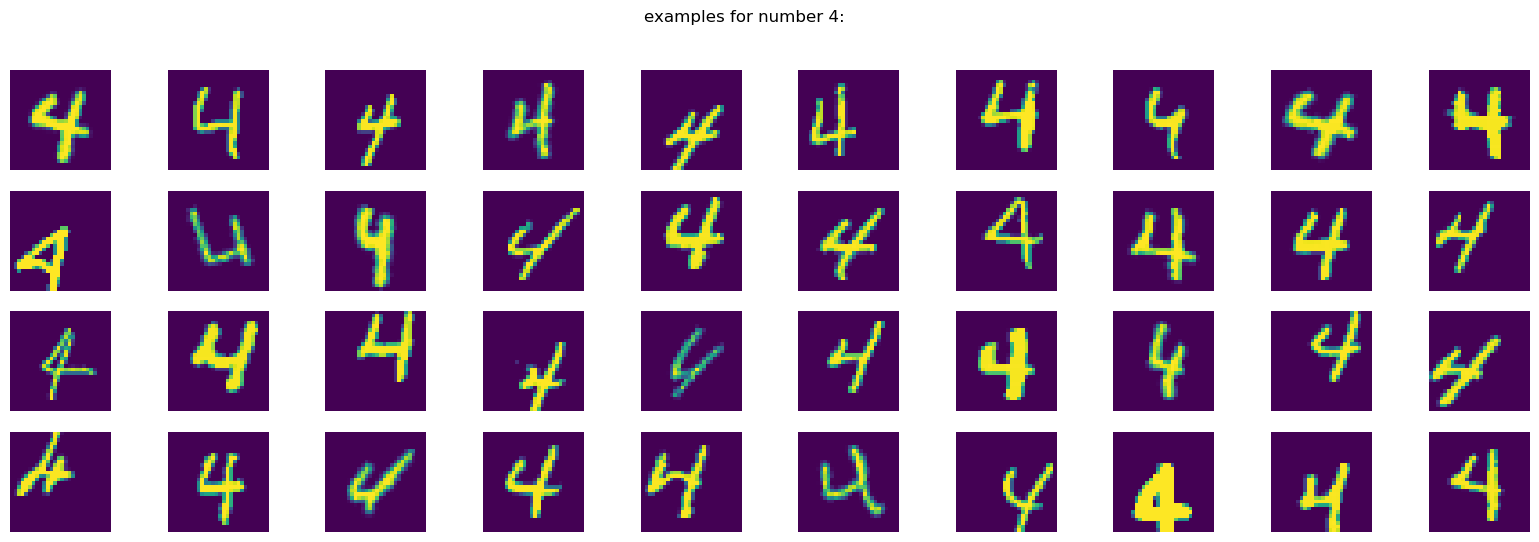

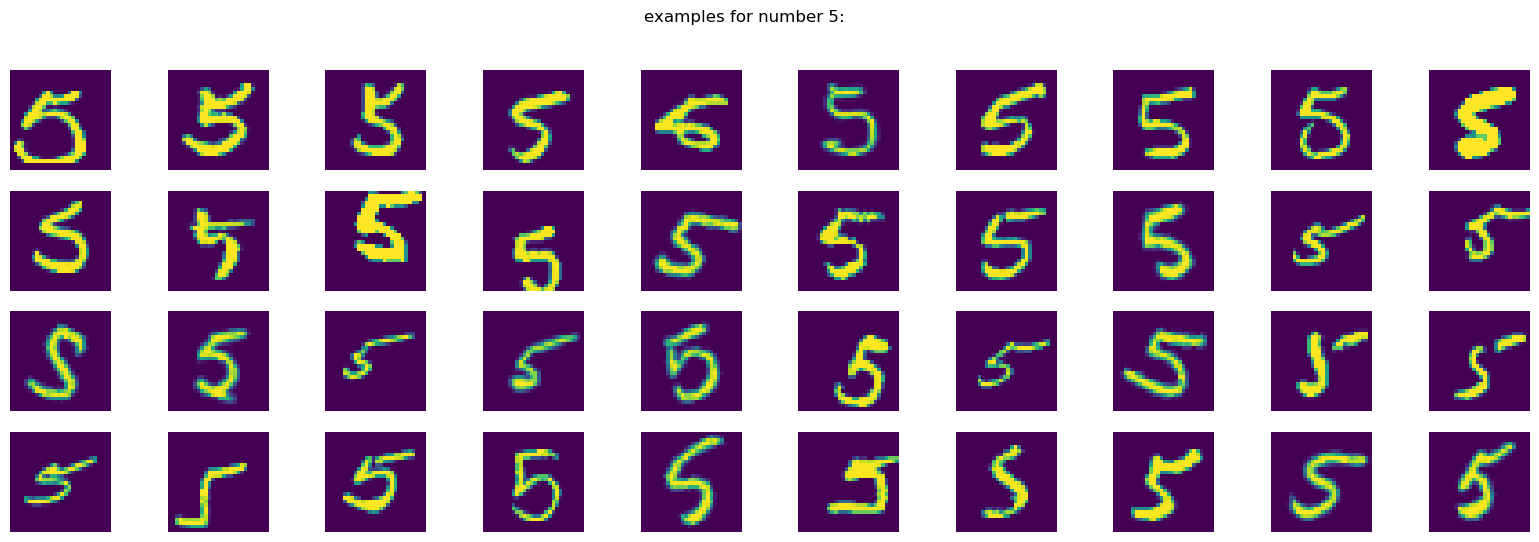

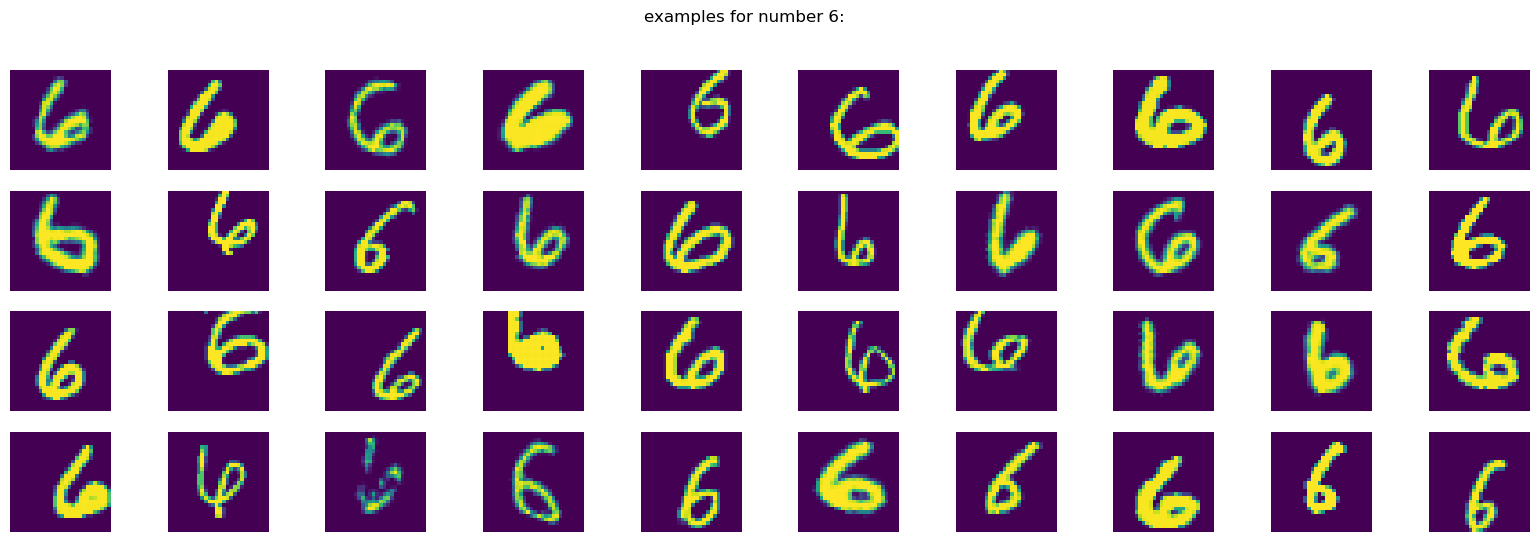

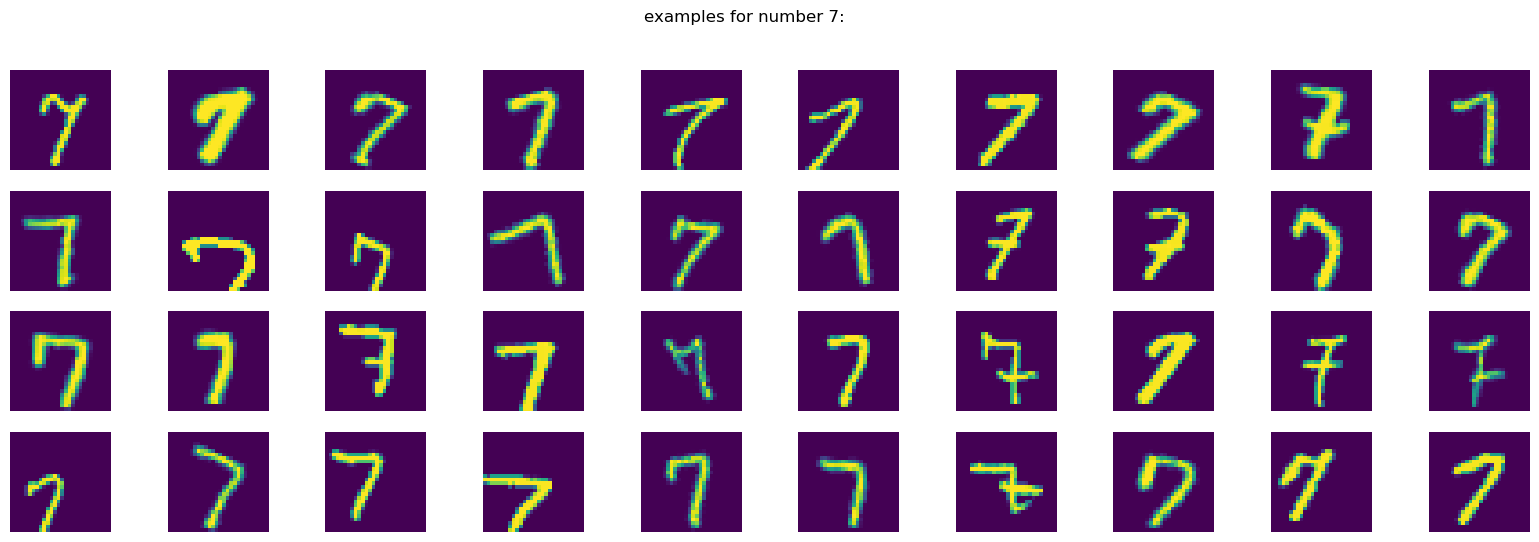

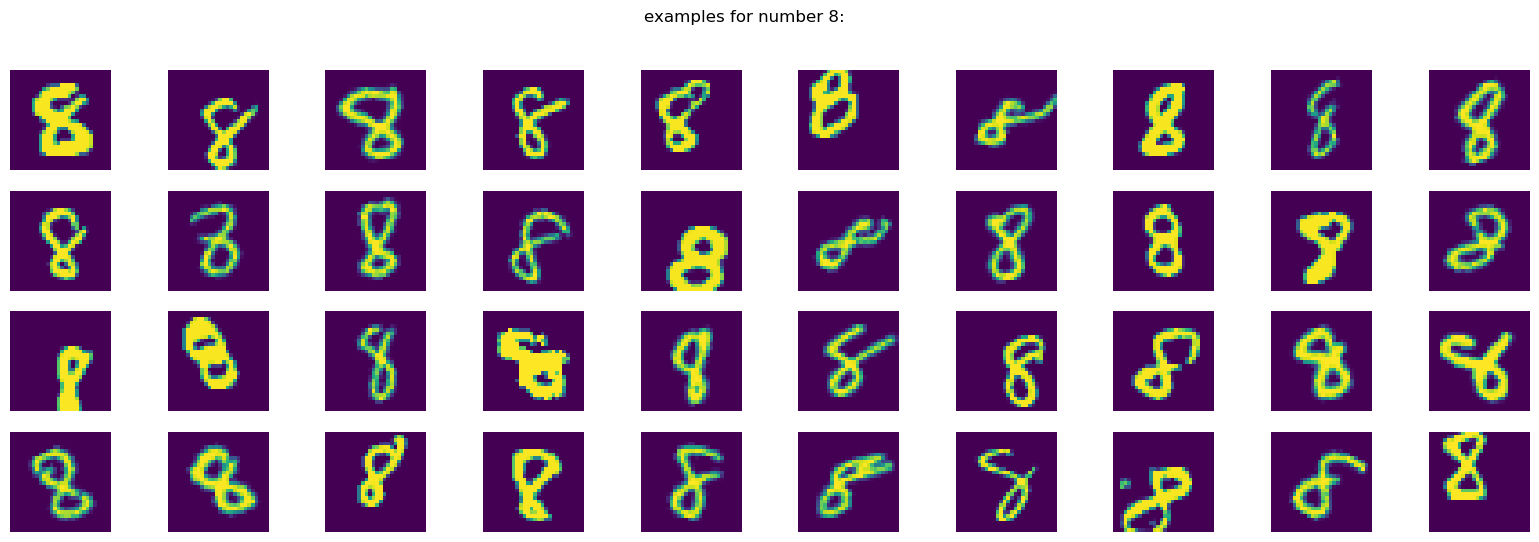

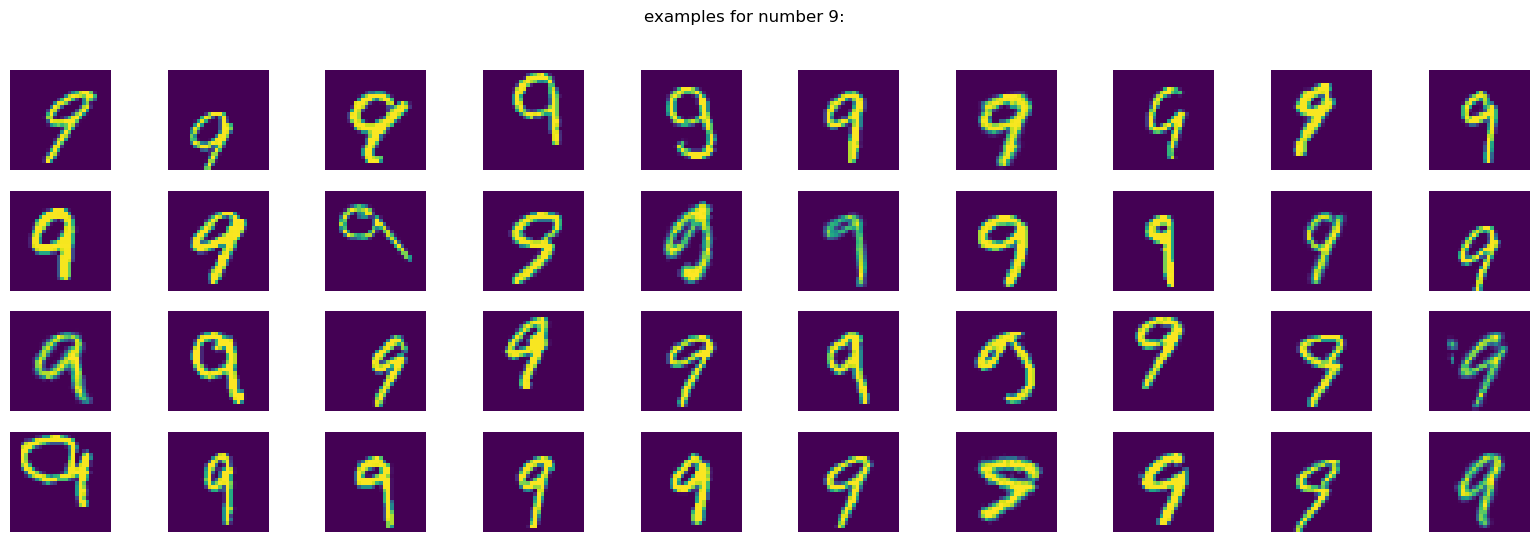

In [24]:
x_test_mixed = np.zeros_like(x_test_img)
y_test_mixed = np.array(y_test).copy()

rng = np.random.default_rng(42)

for i in range(len(x_test_img)):
    choice = rng.integers(0, 3)  # 0=clean, 1=moved, 2=rotate
    
    if choice == 0:
        x_test_mixed[i] = x_test_img[i]
    elif choice == 1:
        x_test_mixed[i] = x_test_moved[i]
    else:
        x_test_mixed[i] = x_test_rotate[i]

# Shuffle final
indices = np.arange(len(x_test_mixed))
rng.shuffle(indices)

x_test_mixed = x_test_mixed[indices]
y_test_mixed = y_test_mixed[indices]

x_test_mixed_flat = x_test_mixed.reshape(len(x_test_mixed), -1)
plot_samples(x_test_mixed, y_test_mixed)

### Results mixed Data : 

In [25]:
evaluate_all_models("mix", x_test_mixed_flat, y_test_mixed)

Stacking_mix -> Accuracy: 0.7526 | F1: 0.7550
model_simple.keras_mix -> Accuracy: 0.8000 | F1: 0.8001
model_drop.keras_mix -> Accuracy: 0.8176 | F1: 0.8188
model_drop_move.keras_mix -> Accuracy: 0.9583 | F1: 0.9582
model_drop_full.keras_mix -> Accuracy: 0.9794 | F1: 0.9794


### Compare all models

In [47]:
results = []

evaluate_all_models("clean", x_test, y_test)
evaluate_all_models("moved", x_test_moved_flat, y_test)
evaluate_all_models("moved_big", x_test_big_moved_flat, y_test)
evaluate_all_models("rotate", x_test_rotate_flat, y_test)
evaluate_all_models("mixed", x_test_mixed_flat, y_test_mixed)


Stacking_clean -> Accuracy: 0.9837 | F1: 0.9837
model_simple.keras_clean -> Accuracy: 0.9851 | F1: 0.9851
model_drop.keras_clean -> Accuracy: 0.9906 | F1: 0.9906
model_drop_move.keras_clean -> Accuracy: 0.9860 | F1: 0.9860
model_drop_full.keras_clean -> Accuracy: 0.9896 | F1: 0.9896
Stacking_moved -> Accuracy: 0.8209 | F1: 0.8197
model_simple.keras_moved -> Accuracy: 0.8988 | F1: 0.8985
model_drop.keras_moved -> Accuracy: 0.9245 | F1: 0.9245
model_drop_move.keras_moved -> Accuracy: 0.9810 | F1: 0.9810
model_drop_full.keras_moved -> Accuracy: 0.9829 | F1: 0.9829
Stacking_moved_big -> Accuracy: 0.3538 | F1: 0.3486
model_simple.keras_moved_big -> Accuracy: 0.4925 | F1: 0.4857
model_drop.keras_moved_big -> Accuracy: 0.5141 | F1: 0.5130
model_drop_move.keras_moved_big -> Accuracy: 0.9634 | F1: 0.9634
model_drop_full.keras_moved_big -> Accuracy: 0.9677 | F1: 0.9677
Stacking_rotate -> Accuracy: 0.9220 | F1: 0.9222
model_simple.keras_rotate -> Accuracy: 0.9231 | F1: 0.9232
model_drop.keras_rot

In [48]:
results_df = pd.DataFrame(results)

clean_df = results_df[results_df["model"].str.endswith("_clean")].sort_values(by="accuracy", ascending=False)
moved_df = results_df[results_df["model"].str.endswith("_moved")].sort_values(by="accuracy", ascending=False)
big_moved_df = results_df[results_df["model"].str.endswith("_big")].sort_values(by="accuracy", ascending=False)
rotate_df = results_df[results_df["model"].str.endswith("_rotate")].sort_values(by="accuracy", ascending=False)
mixed_df = results_df[results_df["model"].str.endswith("_mixed")].sort_values(by="accuracy", ascending=False)

print("CLEAN")
display(clean_df)

print("MOVED")
display(moved_df)

print("BIG MOVED")
display(big_moved_df)

print("ROTATE")
display(rotate_df)

print("MIXED")
display(mixed_df)

CLEAN


,model,accuracy,f1_weighted
2,model_drop.keras_clean,0.9906,0.990601
4,model_drop_full.keras_clean,0.9896,0.989598
3,model_drop_move.keras_clean,0.9860,0.986001
1,model_simple.keras_clean,0.9851,0.985085
0,Stacking_clean,0.9837,0.983697


MOVED


,model,accuracy,f1_weighted
9,model_drop_full.keras_moved,0.9829,0.982895
8,model_drop_move.keras_moved,0.9810,0.980988
7,model_drop.keras_moved,0.9245,0.924452
6,model_simple.keras_moved,0.8988,0.898456
5,Stacking_moved,0.8209,0.819747


BIG MOVED


,model,accuracy,f1_weighted
14,model_drop_full.keras_moved_big,0.9677,0.967750
13,model_drop_move.keras_moved_big,0.9634,0.963436
12,model_drop.keras_moved_big,0.5141,0.512956
11,model_simple.keras_moved_big,0.4925,0.485678
10,Stacking_moved_big,0.3538,0.348649


ROTATE


,model,accuracy,f1_weighted
19,model_drop_full.keras_rotate,0.9817,0.981695
17,model_drop.keras_rotate,0.9448,0.944776
18,model_drop_move.keras_rotate,0.9250,0.924865
16,model_simple.keras_rotate,0.9231,0.923176
15,Stacking_rotate,0.9220,0.922241


MIXED


,model,accuracy,f1_weighted
24,model_drop_full.keras_mixed,0.9794,0.979389
23,model_drop_move.keras_mixed,0.9583,0.958243
22,model_drop.keras_mixed,0.8176,0.818752
21,model_simple.keras_mixed,0.8000,0.800120
20,Stacking_mixed,0.7526,0.755031
